# Credit Card Fraud Detection：不正取引の記述分析と不均衡評価

run_id: `v020-exp-36`。対象は Kaggle `mlg-ulb/creditcardfraud` のみ。全件で頻度と分布を調べ、将来側ホールドアウトで識別評価を行う。accuracy は参考値にとどめ、PR-AUC（Average Precision）、precision、recall、混同行列、誤検知数、検出できた不正金額を示す。分析・取得コードは Jupyter MCP でのみ実行する。API認証情報は表示・保存しない。

In [1]:
from pathlib import Path
import os, sys, json, io, hashlib, zipfile, contextlib, warnings
from datetime import datetime, timezone
from dataclasses import asdict
repo = Path('/home/nahisaho/GitHub/jupytermind')
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity, eda, cleaning, visualization, notebook_audit
run_id = 'v020-exp-36'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-36-credit-card-fraud')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
language = language_router.detect_language('不正取引の頻度、金額・時刻の分布を調べてください')
lifecycle.register_run(run_id, handle.notebook_path)
phase_log = []
@contextlib.contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(run_id):
        raise RuntimeError('キャンセル要求を受信しました')
    lifecycle.mark_execution_start(run_id)
    phase_log.append({'phase': name, 'event': 'execution_start', 'at': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception as exc:
        lifecycle.mark_failed(run_id)
        phase_log.append({'phase': name, 'event': 'failed', 'exception_type': type(exc).__name__})
        raise
    finally:
        lifecycle.mark_execution_end(run_id)
        phase_log.append({'phase': name, 'event': 'execution_end', 'at': datetime.now(timezone.utc).isoformat()})
def write(mutation):
    lifecycle.mark_write_start(run_id)
    phase_log.append({'event': 'write_start', 'at': datetime.now(timezone.utc).isoformat()})
    try:
        return pm.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'event': 'write_end', 'at': datetime.now(timezone.utc).isoformat()})
pending_sections = {}
def section(key, text):
    pending_sections[key] = text
section('intro', '# Credit Card Fraud Detection：不正取引の記述分析と不均衡評価\n\nrun_id: `v020-exp-36`。対象は Kaggle `mlg-ulb/creditcardfraud` のみ。全件で頻度と分布を調べ、将来側ホールドアウトで識別評価を行う。accuracy は参考値にとどめ、PR-AUC（Average Precision）、precision、recall、混同行列、誤検知数、検出できた不正金額を示す。分析・取得コードは Jupyter MCP でのみ実行する。API認証情報は表示・保存しない。')
print('初期化:', language, asdict(lifecycle.get_run_status(run_id)))

初期化: ja {'run_id': 'v020-exp-36', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-36-credit-card-fraud/notebooks/kaggle-v020-kaggle-exp-36-credit-card-fraud.ipynb', 'reason': None}


In [2]:
import logging
from kaggle.api.kaggle_api_extended import KaggleApi
slug = 'mlg-ulb/creditcardfraud'
source_url = 'https://www.kaggle.com/datasets/' + slug
acquisition_errors = []
search_refs, listed_files = [], []
api_success = False
with phase('Kaggle検索・認証・取得'):
    previous_logging_disable = logging.root.manager.disable
    try:
        logging.disable(logging.CRITICAL)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api = KaggleApi()
            api.authenticate()
            matches = api.dataset_list(search='credit card fraud detection')
            search_refs = [str(getattr(d, 'ref', '')) for d in matches]
            file_response = api.dataset_list_files(slug)
            listed_files = [str(getattr(f, 'name', '')) for f in file_response.files]
            if 'creditcard.csv' not in listed_files:
                raise ValueError('指定データセットにcreditcard.csvがありません')
            csv_path = data_dir / 'creditcard.csv'
            if not csv_path.exists():
                api.dataset_download_file(slug, 'creditcard.csv', path=str(data_dir), quiet=True)
            if not csv_path.exists():
                archive = data_dir / 'creditcard.csv.zip'
                if not archive.exists():
                    raise FileNotFoundError('取得CSV・ZIPがありません')
                with zipfile.ZipFile(archive) as zf:
                    if 'creditcard.csv' not in zf.namelist():
                        raise ValueError('ZIP内の対象CSVがありません')
                    csv_path.write_bytes(zf.read('creditcard.csv'))
            api_success = True
    except (Exception, SystemExit) as exc:
        acquisition_errors.append({'stage': 'Kaggle API', 'exception_type': type(exc).__name__, 'message': '認証情報漏洩防止のため例外本文は非記録'})
    finally:
        logging.disable(previous_logging_disable)
    if api_success:
        provenance_path = data_dir / 'provenance.json'
        file_hash = hashlib.sha256(csv_path.read_bytes()).hexdigest()
        if provenance_path.exists():
            provenance = json.loads(provenance_path.read_text())
            if provenance['sha256'] != file_hash or provenance['slug'] != slug:
                raise ValueError('保存済み取得履歴とファイルが一致しません')
            provenance['api_checked_at'] = datetime.now(timezone.utc).isoformat()
        else:
            provenance = {'slug': slug, 'filename': 'creditcard.csv', 'retrieved_at': datetime.now(timezone.utc).isoformat(), 'sha256': file_hash, 'source_url': source_url, 'method': 'Kaggle Python SDK'}
        provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2))
        print('検索結果slug:', search_refs)
        print('対象の公開ファイル:', listed_files)
        print('取得履歴:', json.dumps(provenance, ensure_ascii=False))
    else:
        print('取得失敗:', acquisition_errors)
        white_paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        if white_paper.exists():
            import re
            paper = white_paper.read_text(encoding='utf-8')
            relevant = [line for line in paper.splitlines() if re.search(r'creditcard|credit.card|fraud|不正', line, re.I)]
            print('同一データのフォールバック判定用記述:', '\n'.join(relevant))
        else:
            print('指定white-paper.mdも見つかりません')
        lifecycle.mark_failed(run_id)
section('provenance', '# データ取得履歴\n\n' + ('```json\n' + json.dumps(provenance, ensure_ascii=False, indent=2) + '\n```\nKaggle APIの検索・ファイル一覧で対象を確認。再実行時はSHA-256を検証したローカルCSVを利用し、元の取得日時を保持する。' if api_success else '取得失敗。別データを推測で選ばない。' + json.dumps(acquisition_errors, ensure_ascii=False)))

検索結果slug: ['mlg-ulb/creditcardfraud', 'mishra5001/credit-card', 'nelgiriyewithana/credit-card-fraud-detection-dataset-2023', 'kartik2112/fraud-detection', 'bhadramohit/credit-card-fraud-detection', 'yashpaloswal/fraud-detection-credit-card', 'kaushalnandania/credit-card-fraud-detection', 'shayannaveed/credit-card-fraud-detection', 'uditjain13/credit-card-fraud-detection-2026', 'saurabhbagchi/credit-card-fraud-detection', 'miadul/credit-card-fraud-detection-dataset', 'isaikumar/creditcardfraud', 'aliiihussain/credit-card-fraud-detection', 'divyaraj2006/credit-card-fraud-detection', 'dhruvb2028/credit-card-fraud-dataset', 'joebeachcapital/credit-card-fraud', 'rehanliaqat17/creidct-card', 'chetanmittal033/credit-card-fraud-data', 'computingvictor/transactions-fraud-datasets', 'whenamancodes/fraud-detection']
対象の公開ファイル: ['creditcard.csv']
取得履歴: {"slug": "mlg-ulb/creditcardfraud", "filename": "creditcard.csv", "retrieved_at": "2026-10-01T22:05:57.916303+00:00", "sha256": "76274b691b16a6c49d

# データ取得履歴

```json
{
  "slug": "mlg-ulb/creditcardfraud",
  "filename": "creditcard.csv",
  "retrieved_at": "2026-10-01T22:05:57.916303+00:00",
  "sha256": "76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89",
  "source_url": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud",
  "method": "Kaggle Python SDK",
  "api_checked_at": "2026-10-01T22:13:23.918729+00:00"
}
```
Kaggle APIの検索・ファイル一覧で対象を確認。再実行時はSHA-256を検証したローカルCSVを利用し、元の取得日時を保持する。

In [4]:
import inspect
with phase('データ定義の根拠確認'):
    print('dataset_view:', hasattr(api, 'dataset_view'))
    print('dataset_metadata:', inspect.signature(api.dataset_metadata))
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_metadata(slug, path=str(data_dir))
    metadata_path = data_dir / 'dataset-metadata.json'
    kaggle_metadata = json.loads(metadata_path.read_text())
    print('公開メタデータキー:', list(kaggle_metadata))
    print('公開データ説明取得:', bool(kaggle_metadata['info'].get('description')), 'info.description内に保存')

dataset_view: False
dataset_metadata: (dataset, path)
公開メタデータキー: ['info']
公開データ説明取得: True info.description内に保存


In [5]:
from ai_data_scientist import ingestion
from scipy.stats import mannwhitneyu
with phase('定義manifest・意味的検査・記述統計'):
    if not api_success:
        raise RuntimeError('対象データ取得失敗のため分析を停止')
    info = kaggle_metadata['info']
    print('定義の根拠:', source_url, 'Kaggle API公開descriptionを照合。欧州、2013年9月、2日間、PCA主成分、経過秒、取引金額、Classの定義を確認。通貨は明記なし。')
    initial_assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'dataset':slug, 'planned':'全件記述、時間順60/20/20、検証区間だけで閾値選択'},
        causal_scope='associational',
        assumptions=(
            analysis_assumptions.Assumption('raw-rows','主記述では完全重複も観測行として保持','assumed',impact_if_false='頻度と金額の集計が変わる',conclusion_critical=True),
            analysis_assumptions.Assumption('iid-reference','Wilson区間と順位検定は取引独立性を仮定','assumed',impact_if_false='推論不確実性が過小となりうる',conclusion_critical=True),
            analysis_assumptions.Assumption('fixed-policy','F2を探索的なrecall重視ポリシーとして選ぶ','assumed',impact_if_false='実コストに最適とは限らない',conclusion_critical=True)))
    initial_assumption_findings=analysis_assumptions.check_manifest(initial_assumptions)
    display({'分析前の前提':asdict(initial_assumptions),'警告':[asdict(x) for x in initial_assumption_findings]})
    section('assumptions_initial','# 分析前の前提manifest\n\n```json\n'+json.dumps(asdict(initial_assumptions),ensure_ascii=False,indent=2)+'\n```\n\n重複保持・独立性・F2選択は解析前にはassumed。重複の影響と閾値の感度は反復で検証し、独立性と実コストは最後まで未解決として報告する。')
    FV = data_definition.FieldValue
    variables = {
        'Time': {'definition': FV('最初の取引からの経過時間', 'verified', source_url), 'unit': FV('秒', 'verified', source_url), 'clock_origin': FV(None, 'unknown', source_url)},
        'Amount': {'definition': FV('取引金額', 'verified', source_url), 'currency': FV(None, 'unknown', source_url), 'loss_equivalence': FV(None, 'unknown', source_url)},
        'Class': {'definition': FV('1=不正、0=正常', 'verified', source_url), 'label_delay': FV(None, 'unknown', source_url)},
    }
    for col in [f'V{i}' for i in range(1,29)]:
        variables[col] = {'definition': FV('匿名化されたPCA主成分', 'verified', source_url), 'original_feature': FV(None, 'unknown', source_url), 'pca_fit_scope': FV(None, 'unknown', source_url)}
    definition_manifest = data_definition.build_manifest(
        source={k: FV(v, 'verified', source_url) for k,v in provenance.items()},
        dataset_scope={'population': FV('欧州カード保有者、2013年9月の2日間', 'verified', source_url), 'independent_transactions': FV(None, 'unknown', source_url), 'license': FV(info['licenses'], 'verified', source_url)},
        variables=variables,
        transformations=('解析用経過時間=Time/3600', 'モデル金額=log1p(Amount)、学習期間だけで標準化'))
    unresolved_definitions = [name for name, value in definition_manifest.unresolved_fields()]
    print('未解決の定義:', unresolved_definitions)
    ingested = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=500000)
    df = ingested.dataframe
    expected = ['Time'] + [f'V{i}' for i in range(1,29)] + ['Amount','Class']
    assert list(df.columns) == expected, 'スキーマ不一致'
    assert not ingested.truncated, '全件取得が必要'
    schema = {c: {'not_null': True} for c in expected}
    schema.update({'Time': {'min':0,'not_null':True}, 'Amount': {'min':0,'not_null':True}, 'Class': {'allowed':[0,1],'not_null':True}})
    semantic_anomalies = data_quality.detect_anomalies(df, schema)
    finite_bad = int((~np.isfinite(df.to_numpy())).sum())
    duplicate_count = int(df.duplicated().sum())
    features = expected[:-1]
    conflicting_labels = int(df.groupby(features, dropna=False)['Class'].nunique().gt(1).sum())
    eda_report = eda.explore(df)
    print('検査:', {'rows':len(df),'columns':len(df.columns),'semantic_violations':[asdict(x) for x in semantic_anomalies], 'nonfinite':finite_bad,'duplicate_rows':duplicate_count,'conflicting_label_groups':conflicting_labels, 'zero_amount':int(df.Amount.eq(0).sum()),'time_monotonic':bool(df.Time.is_monotonic_increasing)})
    display(pd.DataFrame({'dtype':eda_report.dtypes, 'non_null':eda_report.non_null_counts, 'missing':{c:eda_report.missing_summary[c]['missing_count'] for c in expected}}))
    assert not semantic_anomalies and finite_bad == 0 and conflicting_labels == 0
    counts = df.Class.value_counts().sort_index()
    n, k = len(df), int(counts[1])
    prevalence = k/n
    z=1.959963984540054
    center=(prevalence+z*z/(2*n))/(1+z*z/n)
    half=z*np.sqrt(prevalence*(1-prevalence)/n+z*z/(4*n*n))/(1+z*z/n)
    frequency = pd.DataFrame({'class':['正常','不正'], 'count':[int(counts[0]),k], 'percent':[100*(1-prevalence),100*prevalence]})
    display(frequency)
    print(f'不正率={prevalence:.8f}; 不正件数={k}; Wilson95%区間=[{center-half:.8f}, {center+half:.8f}]; 全正常accuracy={1-prevalence:.8f}')
    amount_summary = df.groupby('Class').Amount.describe(percentiles=[.25,.5,.75,.9,.95,.99])
    amount_summary['sum']=df.groupby('Class').Amount.sum()
    amount_summary['zero_count']=df.groupby('Class').Amount.apply(lambda s:s.eq(0).sum())
    display(amount_summary)
    print('経過時間範囲(時間):', df.Time.min()/3600, df.Time.max()/3600)
    time_summary = df.groupby('Class').Time.describe(percentiles=[.25,.5,.75]) / 3600
    time_summary['count'] = df.groupby('Class').size()
    display(time_summary)
    effect_rows=[]
    for col in ['Amount','Time']+[f'V{i}' for i in range(1,29)]:
        a,b=df.loc[df.Class.eq(1),col], df.loc[df.Class.eq(0),col]
        stat=mannwhitneyu(a,b, alternative='two-sided', method='asymptotic')
        effect_rows.append({'feature':col,'normal_median':b.median(),'fraud_median':a.median(),'cliffs_delta':2*stat.statistic/(len(a)*len(b))-1,'p_value':stat.pvalue})
    effects=pd.DataFrame(effect_rows)
    effects['abs_delta']=effects.cliffs_delta.abs()
    sorted_p=effects.p_value.sort_values()
    bh=(sorted_p*len(effects)/np.arange(1,len(effects)+1)).iloc[::-1].cummin().iloc[::-1].clip(upper=1)
    effects['q_BH']=bh
    display(effects.sort_values('abs_delta',ascending=False).head(12))
    display(effects[effects.feature.isin(['Amount','Time'])])
    results={'n':n,'fraud_count':k,'prevalence':prevalence,'majority_accuracy':1-prevalence,'amount_medians':amount_summary['50%'].to_dict(),'amount_means':amount_summary['mean'].to_dict(),'fraud_amount_share':float(amount_summary.loc[1,'sum']/amount_summary['sum'].sum()),'duplicates':duplicate_count}
    display({'初回記述結果': results})
section('definitions', '# データ定義manifest・解釈上の制約\n\n```json\n'+json.dumps(asdict(definition_manifest),ensure_ascii=False,indent=2)+'\n```\n\n`Time`は経過秒であり実時刻・現地時間帯ではない。「深夜」「営業時間」とは解釈しない。Amountの通貨は取得した説明に明記されていないため元データ単位で示す。V1–V28はPCA主成分であり、商品・地域・年齢などへ対応づけたり因果説明したりできない。PCAの学習対象も不明。カードIDがないため顧客分離・再発・独立性を検証できない。不正ラベル確定遅延と実損失も不明。Wilson区間は独立Bernoulli仮定下の参考値で、母集団一般化の保証ではない。')
section('applicability', '# 適用しない機能と理由\n\n独立参照データが指定・取得されていないため `data_quality.validate_anomalies` と `dataset_validation.compare_datasets` は適用しない。同じCSVの複製や時系列部分集合を独立データと偽らない。API取得はKaggle SDKで直接実施し、ingestionは検証済みローカルCSVの読み込みに利用。mcp_gateway.run_and_recordは直接Jupyter MCP実行を二重ラップしないため未使用。AutoML・クラスタリング・因果推定は本依頼の範囲外。金額の極端値・ゼロ、繰り返し時刻を不正・誤りと自動認定しない。完全重複は主解析では保持し、反復で除外感度を確認する。')

定義の根拠: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud Kaggle API公開descriptionを照合。欧州、2013年9月、2日間、PCA主成分、経過秒、取引金額、Classの定義を確認。通貨は明記なし。
未解決の定義: ['dataset_scope.independent_transactions', 'variables.Time.clock_origin', 'variables.Amount.currency', 'variables.Amount.loss_equivalence', 'variables.Class.label_delay', 'variables.V1.original_feature', 'variables.V1.pca_fit_scope', 'variables.V2.original_feature', 'variables.V2.pca_fit_scope', 'variables.V3.original_feature', 'variables.V3.pca_fit_scope', 'variables.V4.original_feature', 'variables.V4.pca_fit_scope', 'variables.V5.original_feature', 'variables.V5.pca_fit_scope', 'variables.V6.original_feature', 'variables.V6.pca_fit_scope', 'variables.V7.original_feature', 'variables.V7.pca_fit_scope', 'variables.V8.original_feature', 'variables.V8.pca_fit_scope', 'variables.V9.original_feature', 'variables.V9.pca_fit_scope', 'variables.V10.original_feature', 'variables.V10.pca_fit_scope', 'variables.V11.original_feature', 'variables.V1

{'分析前の前提': {'analysis_scope': {'dataset': 'mlg-ulb/creditcardfraud',
   'planned': '全件記述、時間順60/20/20、検証区間だけで閾値選択'},
  'assumptions': ({'id': 'raw-rows',
    'statement': '主記述では完全重複も観測行として保持',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_if_false': '頻度と金額の集計が変わる',
    'conclusion_critical': True},
   {'id': 'iid-reference',
    'statement': 'Wilson区間と順位検定は取引独立性を仮定',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_if_false': '推論不確実性が過小となりうる',
    'conclusion_critical': True},
   {'id': 'fixed-policy',
    'statement': 'F2を探索的なrecall重視ポリシーとして選ぶ',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_if_false': '実コストに最適とは限らない',
    'conclusion_critical': True}),
  'causal_scope': 'associational',
  'sampling': None},
 '警告': [{'code': 'unresolved_conclusion_critical_assumption',
   'severity': 'warning',
   'message': "Conclusion-critical assumption 'raw-rows' has status 'assumed', not verified/tested.",
   'assumption_id': 'raw-rows'},
  {'code'

,dtype,non_null,missing
Time,float64,284807,0
V1,float64,284807,0
V2,float64,284807,0
V3,float64,284807,0
V4,float64,284807,0
V5,float64,284807,0
V6,float64,284807,0
V7,float64,284807,0
V8,float64,284807,0
V9,float64,284807,0


,class,count,percent
0,正常,284315,99.827251
1,不正,492,0.172749


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,sum,zero_count
Class,,,,,,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,202.724,364.409,1016.9664,25691.16,25102462.04,1798
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,346.746,640.905,1357.4279,2125.87,60127.97,27


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315,26.343945,13.190004,0.000000,15.063889,23.530833,38.703611,47.997778
1,492,22.429669,13.287601,0.112778,11.455972,20.991250,35.689722,47.318889


,feature,normal_median,fraud_median,cliffs_delta,p_value,abs_delta,q_BH
15,V14,0.051947,-6.729720,-0.898319,1.471581e-260,0.898319,4.414742e-259
5,V4,-0.022405,4.177147,0.876517,3.625904e-248,0.876517,5.438857e-247
13,V12,0.141679,-5.502530,-0.874081,8.416027e-247,0.874081,8.416027e-246
12,V11,-0.034923,3.586218,0.836166,4.910592e-226,0.836166,3.682944e-225
11,V10,-0.091872,-4.578825,-0.828115,9.611131e-222,0.828115,5.766679e-221
4,V3,0.182158,-5.075257,-0.824146,1.211048e-219,0.824146,6.055240e-219
3,V2,0.064070,2.717869,0.709910,1.650438e-163,0.709910,7.073304e-163
17,V16,0.067377,-3.549795,-0.694263,1.808172e-156,0.694263,6.780646e-156
10,V9,-0.049964,-2.208768,-0.688180,8.943723e-154,0.688180,2.981241e-153
8,V7,0.041138,-3.034402,-0.671623,1.464234e-146,0.671623,4.392701e-146


,feature,normal_median,fraud_median,cliffs_delta,p_value,abs_delta,q_BH
0,Amount,22.0,9.25,-0.115927,8.578472e-06,0.115927,1.072309e-05
1,Time,84711.0,75568.50,-0.162552,4.386159e-10,0.162552,5.981126e-10


{'初回記述結果': {'n': 284807,
  'fraud_count': 492,
  'prevalence': 0.001727485630620034,
  'majority_accuracy': 0.9982725143693799,
  'amount_medians': {0: 22.0, 1: 9.25},
  'amount_means': {0: 88.29102242231328, 1: 122.21132113821139},
  'fraud_amount_share': 0.002389577939953885,
  'duplicates': 1081}}

時間別不正率上位（件数と分母を併記）:


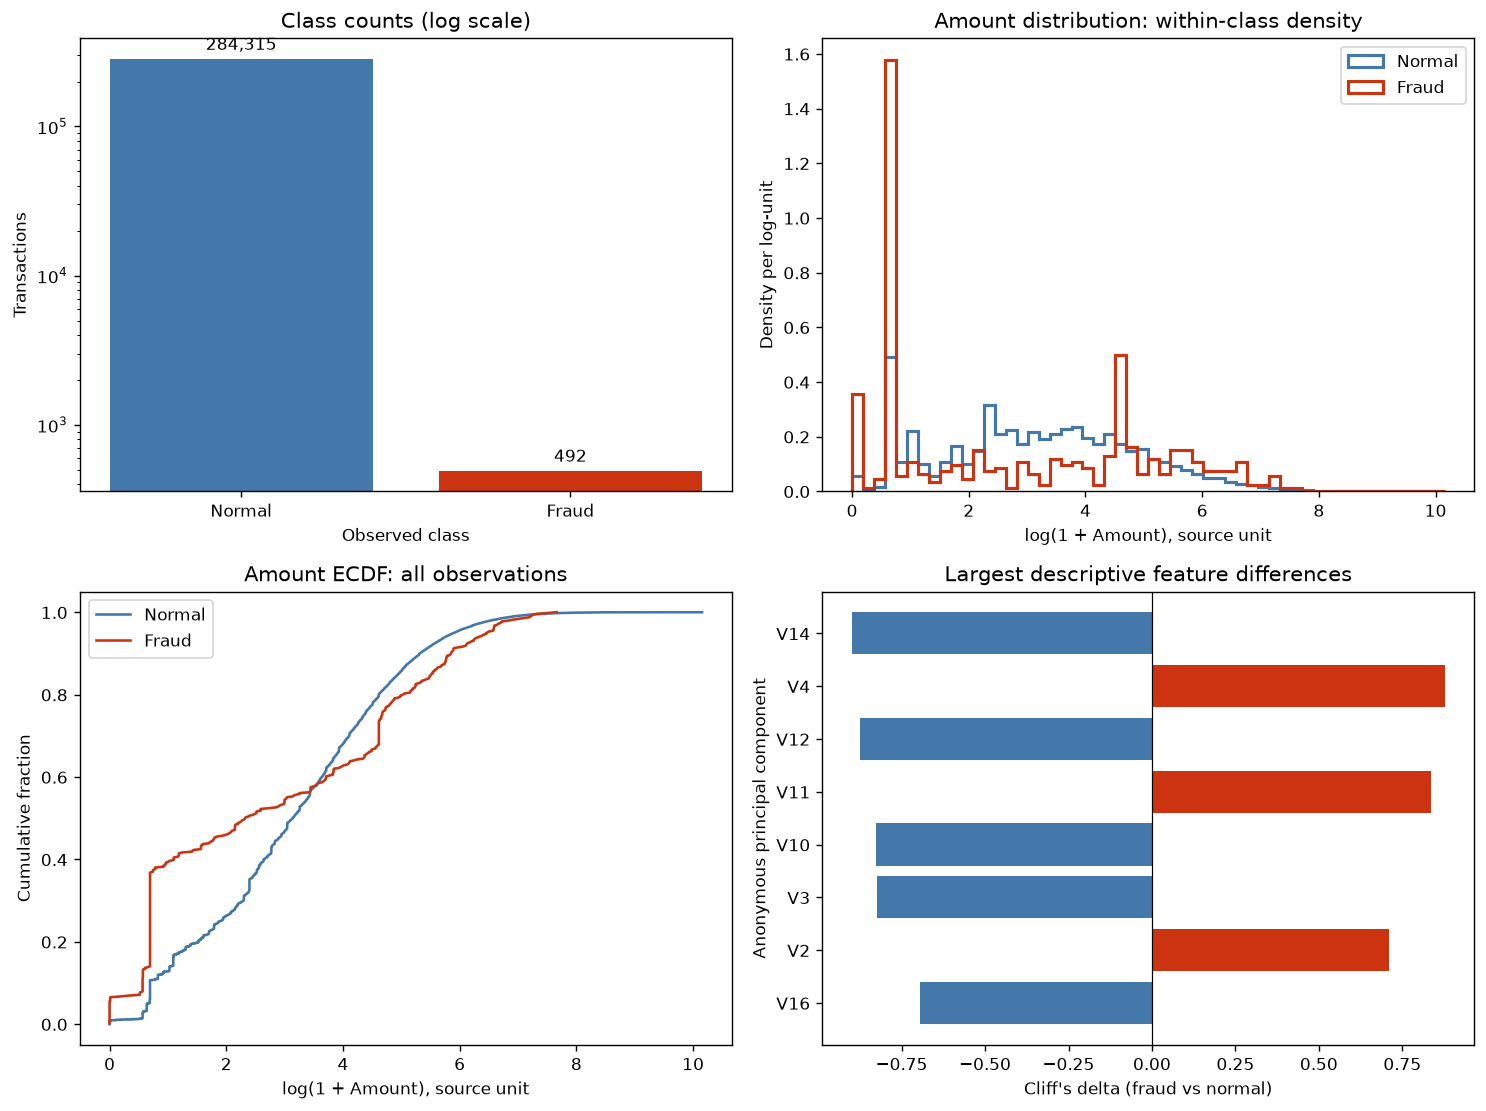

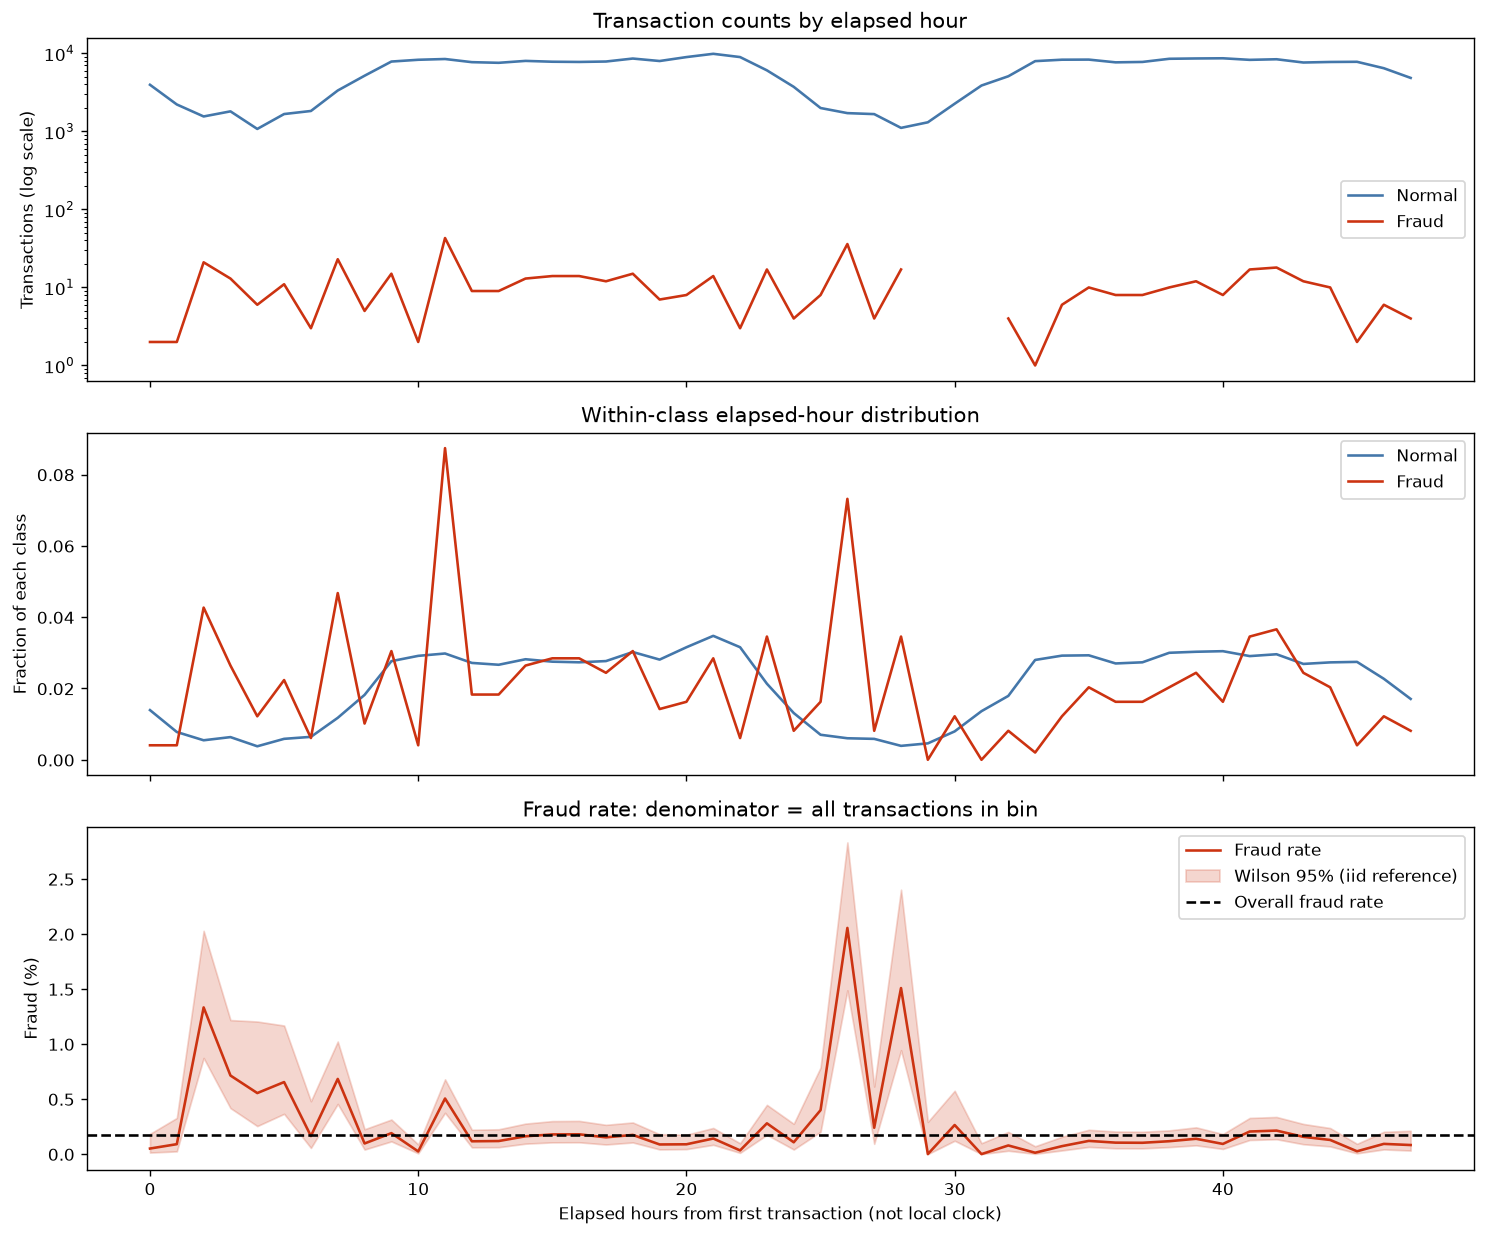

,n,fraud,fraud_rate,normal,ci_low,ci_high
elapsed_hour,,,,,,
26,1752,36,0.020548,1716,0.014879,0.028315
28,1127,17,0.015084,1110,0.009439,0.024024
2,1576,21,0.013325,1555,0.008732,0.020285
3,1821,13,0.007139,1808,0.004177,0.012176
7,3368,23,0.006829,3345,0.004555,0.010227
5,1681,11,0.006544,1670,0.003658,0.011680
4,1082,6,0.005545,1076,0.002544,0.012045
11,8517,43,0.005049,8474,0.003751,0.006793


In [6]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
pending_charts = {}
def show_chart(fig, key, title, xlabel, ylabel, legend):
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        buffer=io.BytesIO()
        fig.savefig(buffer, format='png', dpi=125, bbox_inches='tight')
    missing = [str(w.message) for w in captured if 'Glyph' in str(w.message)]
    for w in captured:
        if 'Glyph' not in str(w.message):
            warnings.warn(str(w.message), w.category)
    pending_charts[key]={'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':missing,'inspection':'各軸のタイトル・単位・凡例は作者が確認。全件またはクラス内正規化。'}
    image=visualization.build_image_output(buffer.getvalue())
    display(image['data'], raw=True)
    plt.close(fig)
with phase('分布図の作成'):
    fig, axes=plt.subplots(2,2,figsize=(12,9))
    ax=axes[0,0]
    ax.bar(['Normal','Fraud'], [counts[0],counts[1]],color=['#4477aa','#cc3311'])
    ax.set_yscale('log'); ax.set_title('Class counts (log scale)'); ax.set_xlabel('Observed class'); ax.set_ylabel('Transactions')
    for i,c in enumerate([counts[0],counts[1]]): ax.text(i,c*1.15,f'{c:,}',ha='center')
    edges=np.linspace(0,np.log1p(df.Amount.max()),55)
    for c,label,color in [(0,'Normal','#4477aa'),(1,'Fraud','#cc3311')]:
        axes[0,1].hist(np.log1p(df.loc[df.Class.eq(c),'Amount']),bins=edges,density=True,histtype='step',label=label,color=color,linewidth=1.8)
        values=np.sort(df.loc[df.Class.eq(c),'Amount'].to_numpy())
        axes[1,0].plot(np.log1p(values),np.arange(1,len(values)+1)/len(values),label=label,color=color)
    axes[0,1].set(title='Amount distribution: within-class density',xlabel='log(1 + Amount), source unit',ylabel='Density per log-unit'); axes[0,1].legend()
    axes[1,0].set(title='Amount ECDF: all observations',xlabel='log(1 + Amount), source unit',ylabel='Cumulative fraction'); axes[1,0].legend()
    top=effects.sort_values('abs_delta').tail(8)
    axes[1,1].barh(top.feature,top.cliffs_delta,color=np.where(top.cliffs_delta.gt(0),'#cc3311','#4477aa'))
    axes[1,1].set(title='Largest descriptive feature differences',xlabel="Cliff's delta (fraud vs normal)",ylabel='Anonymous principal component'); axes[1,1].axvline(0,color='black',linewidth=.7)
    fig.tight_layout()
    show_chart(fig,'distributions','Class imbalance, Amount distribution and feature effects','Class / log(1+Amount) / Cliff delta','Count / density / ECDF / PCA feature','Normal, Fraud; signed effect')
    hourly=df.assign(elapsed_hour=np.floor(df.Time/3600).astype(int)).groupby('elapsed_hour').Class.agg(n='size',fraud='sum')
    hourly['fraud_rate']=hourly.fraud/hourly.n
    hourly['normal']=hourly.n-hourly.fraud
    h=hourly.fraud_rate.to_numpy(); total=hourly.n.to_numpy()
    hc=(h+z*z/(2*total))/(1+z*z/total); hw=z*np.sqrt(h*(1-h)/total+z*z/(4*total**2))/(1+z*z/total)
    hourly['ci_low']=hc-hw; hourly['ci_high']=hc+hw
    fig,axes=plt.subplots(3,1,figsize=(12,10),sharex=True)
    for col,label,color in [('normal','Normal','#4477aa'),('fraud','Fraud','#cc3311')]:
        axes[0].plot(hourly.index,hourly[col].where(hourly[col].gt(0)),label=label,color=color)
        axes[1].plot(hourly.index,hourly[col]/hourly[col].sum(),label=label,color=color)
    axes[0].set(title='Transaction counts by elapsed hour',ylabel='Transactions (log scale)',yscale='log'); axes[0].legend()
    axes[1].set(title='Within-class elapsed-hour distribution',ylabel='Fraction of each class'); axes[1].legend()
    axes[2].plot(hourly.index,100*h,label='Fraud rate',color='#cc3311')
    axes[2].fill_between(hourly.index,100*hourly.ci_low,100*hourly.ci_high,alpha=.2,color='#cc3311',label='Wilson 95% (iid reference)')
    axes[2].axhline(100*prevalence,linestyle='--',color='black',label='Overall fraud rate')
    axes[2].set(title='Fraud rate: denominator = all transactions in bin',xlabel='Elapsed hours from first transaction (not local clock)',ylabel='Fraud (%)'); axes[2].legend()
    fig.tight_layout()
    show_chart(fig,'elapsed_time','Counts, normalized distributions and rate by elapsed hour','Elapsed hours, not local clock','Count / class fraction / fraud percent','Normal, Fraud, Wilson 95%, overall fraud rate')
    print('時間別不正率上位（件数と分母を併記）:')
    display(hourly.sort_values('fraud_rate',ascending=False).head(8))
section('charts', '# 図表の選択と読み方\n\nクラス件数は対数軸、金額分布はクラス別に正規化したlog1pヒストグラムとECDFで、少数クラスが埋もれないようにした。時間別では件数、クラス内構成比、不正率を別軸に分け、分母とWilson区間を併記する。最後の時間帯は観測終了による部分区間であり、一時間全体の件数と同等に扱わない。V特徴の順位は全データの記述的効果量で、モデル特徴選択には利用しない。p値は独立性仮定に依存するため、BH補正後でも業務上の意味・因果関係を示さない。')

固定境界(秒): 120396.0 145247.80000000002
検証で選んだ閾値: 0.9999211811659731 検証AP: 0.7569657364161537
初回テストAP: 0.7473703891537652 テスト不正率: 0.001316667251852112


,split,n,fraud,prevalence,start_hour,end_hour
0,train,170882,360,0.002107,0.000000,33.443056
1,validation,56963,57,0.001001,33.443333,40.346389
2,test,56962,75,0.001317,40.346667,47.997778


,model,threshold,AP,ROC_AUC,precision,recall,F2,balanced_accuracy,MCC,accuracy,TP,FP,FN,TN,FP_per_10000_normal,alerts,amount_recall
0,Always normal,1.000000,0.001317,0.500000,0.000000,0.000000,0.000000,0.500000,0.000000,0.998683,0,0,75,56887,0.000000,0,0.000000
1,LR balanced: 0.5,0.500000,0.747370,0.981828,0.043563,0.893333,0.182263,0.933738,0.194074,0.974035,67,1471,8,55416,258.582805,1538,0.697086
2,LR balanced: validation F2,0.999921,0.747370,0.981828,0.812500,0.693333,0.714286,0.846561,0.750254,0.999386,52,12,23,56875,2.109445,64,0.611130


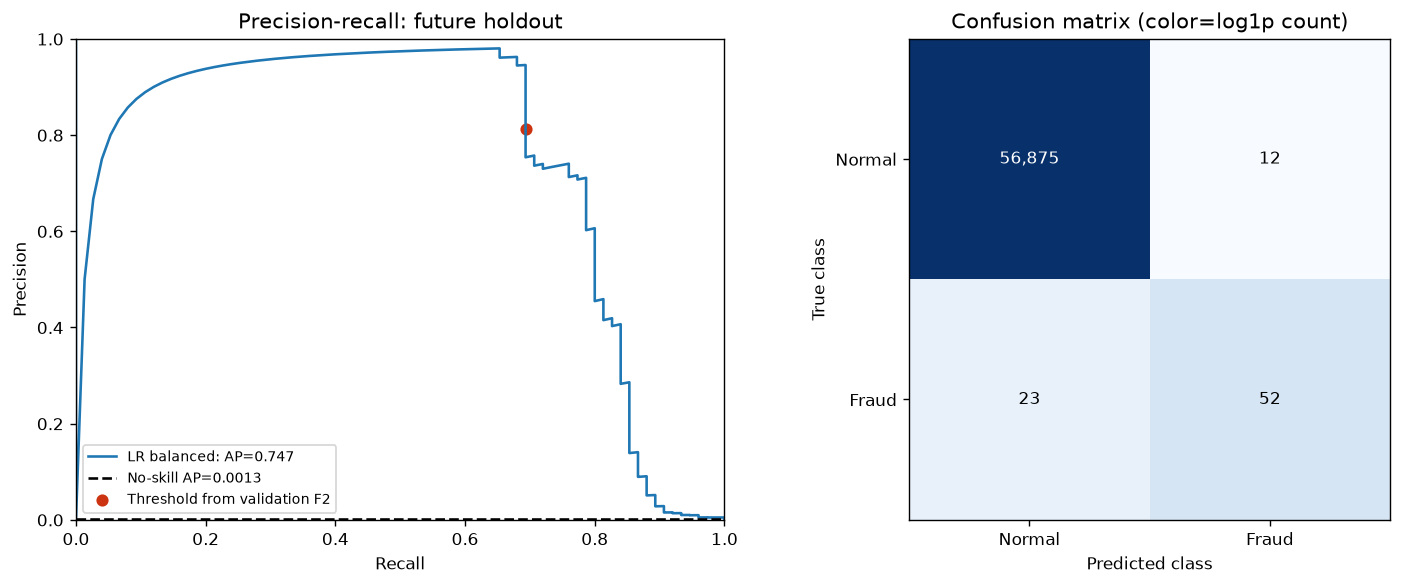

{'初回評価': {'model': 'LR balanced: validation F2',
  'threshold': 0.9999211811659731,
  'AP': 0.7473703891537652,
  'ROC_AUC': 0.9818280685100873,
  'precision': 0.8125,
  'recall': 0.6933333333333334,
  'F2': 0.7142857142857143,
  'balanced_accuracy': 0.8465611944146583,
  'MCC': 0.7502544625531906,
  'accuracy': 0.999385555282469,
  'TP': 52,
  'FP': 12,
  'FN': 23,
  'TN': 56875,
  'FP_per_10000_normal': 2.1094450401673495,
  'alerts': 64,
  'amount_recall': 0.611129655361574}}

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix, accuracy_score, balanced_accuracy_score, matthews_corrcoef
from threadpoolctl import threadpool_limits
with phase('初回モデル評価・時系列ホールドアウト'):
    cut_train, cut_test = df.Time.quantile([.6,.8]).to_numpy()
    train=df[df.Time.lt(cut_train)].copy()
    valid=df[df.Time.ge(cut_train) & df.Time.lt(cut_test)].copy()
    test=df[df.Time.ge(cut_test)].copy()
    splits=pd.DataFrame([{'split':name,'n':len(d),'fraud':int(d.Class.sum()),'prevalence':d.Class.mean(),'start_hour':d.Time.min()/3600,'end_hour':d.Time.max()/3600} for name,d in [('train',train),('validation',valid),('test',test)]])
    print('固定境界(秒):',cut_train,cut_test)
    display(splits)
    assert train.Time.max()<valid.Time.min() and valid.Time.max()<test.Time.min()
    def model_features(frame):
        out=frame.drop(columns=['Class'],errors='ignore').copy()
        out['Amount']=np.log1p(out['Amount'])
        out['Time']=out['Time']/3600
        return out
    def logistic_model(C=1.0, class_weight='balanced'):
        return make_pipeline(FunctionTransformer(model_features),StandardScaler(),LogisticRegression(C=C,class_weight=class_weight,max_iter=1000,random_state=36))
    def f2_threshold(y,scores):
        p,r,t=precision_recall_curve(y,scores)
        f2=5*p[:-1]*r[:-1]/np.maximum(4*p[:-1]+r[:-1],1e-15)
        return float(t[np.argmax(f2)])
    def metrics(y,scores,threshold,amount, name):
        pred=scores>=threshold
        tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
        amount=np.asarray(amount); y=np.asarray(y)
        return {'model':name,'threshold':float(threshold),'AP':average_precision_score(y,scores),'ROC_AUC':roc_auc_score(y,scores),'precision':tp/(tp+fp) if tp+fp else 0.,'recall':tp/(tp+fn),'F2':5*tp/(5*tp+4*fn+fp),'balanced_accuracy':balanced_accuracy_score(y,pred),'MCC':matthews_corrcoef(y,pred),'accuracy':accuracy_score(y,pred),'TP':int(tp),'FP':int(fp),'FN':int(fn),'TN':int(tn),'FP_per_10000_normal':float(fp/(tn+fp)*10000),'alerts':int(tp+fp),'amount_recall':float(amount[(y==1)&pred].sum()/amount[y==1].sum())}
    primary=logistic_model()
    with threadpool_limits(limits=1):
        primary.fit(train[features],train.Class)
        val_score=primary.predict_proba(valid[features])[:,1]
        test_score=primary.predict_proba(test[features])[:,1]
    selected_threshold=f2_threshold(valid.Class,val_score)
    initial_metrics=pd.DataFrame([
        metrics(test.Class,np.zeros(len(test)),1,test.Amount,'Always normal'),
        metrics(test.Class,test_score,.5,test.Amount,'LR balanced: 0.5'),
        metrics(test.Class,test_score,selected_threshold,test.Amount,'LR balanced: validation F2')])
    display(initial_metrics)
    print('検証で選んだ閾値:',selected_threshold,'検証AP:',average_precision_score(valid.Class,val_score))
    print('初回テストAP:',average_precision_score(test.Class,test_score),'テスト不正率:',test.Class.mean())
    fig,axes=plt.subplots(1,2,figsize=(12,4.8))
    p,r,_=precision_recall_curve(test.Class,test_score)
    axes[0].plot(r,p,label=f'LR balanced: AP={average_precision_score(test.Class,test_score):.3f}')
    axes[0].axhline(test.Class.mean(),color='black',linestyle='--',label=f'No-skill AP={test.Class.mean():.4f}')
    chosen=initial_metrics.iloc[-1]
    axes[0].scatter([chosen.recall],[chosen.precision],color='#cc3311',label='Threshold from validation F2')
    axes[0].set(title='Precision-recall: future holdout',xlabel='Recall',ylabel='Precision',xlim=(0,1),ylim=(0,1)); axes[0].legend(fontsize=8)
    cm=confusion_matrix(test.Class,test_score>=selected_threshold,labels=[0,1])
    axes[1].imshow(np.log1p(cm),cmap='Blues')
    for i in range(2):
        for j in range(2): axes[1].text(j,i,f'{cm[i,j]:,}',ha='center',va='center',color='white' if i==j==0 else 'black')
    axes[1].set(title='Confusion matrix (color=log1p count)',xlabel='Predicted class',ylabel='True class',xticks=[0,1],yticks=[0,1],xticklabels=['Normal','Fraud'],yticklabels=['Normal','Fraud'])
    fig.tight_layout()
    show_chart(fig,'primary_evaluation','Precision-recall and confusion matrix, future holdout','Recall / predicted class','Precision / true class','LR, no-skill baseline, validation F2; cells show counts')
    display({'初回評価':initial_metrics.iloc[-1].to_dict()})
section('evaluation', '# 不均衡を前提にした評価設計\n\nTimeの60%・80%点を固定境界にして、同一時刻が異なる区間へまたがらないよう学習・検証・テストを分割した。変換と標準化は学習区間のみでfit、閾値は検証区間のF2最大化（recall重視）で選ぶ。SMOTE・under-samplingは行わず、テストの自然な不正率を保持する。学習のclass_weightはbalancedであり、スコアを較正済み不正確率とは解釈しない。APは非補間Average Precisionで、台形積分のPR-AUCとは区別する。ROC-AUCは補助指標。全正常ベースラインは不正recall=0であり、accuracyが高くても役に立たない。amount_recallは検出不正取引金額の割合であり、回収損失や利益ではない。全データEDAを見た後の探索評価なので外部検証なしに運用性能を保証しない。')

In [8]:
iteration_history = []
request1 = '完全重複1,081行と金額の右裾が、不正頻度・平均と中央値の逆転・時間帯の偏りという結論を変えるか確認してください。重複保持／除外、金額上位1%の影響、1・2・4時間幅を比較し、経過時間の区間ごとの分母も示してください。'
with phase('反復1：重複・金額裾・時間集約の感度'):
    dedup_report=cleaning.clean_dataset(df,operation='drop_duplicates')
    dedup=dedup_report.dataframe
    print('クリーニング影響:',{'rows_before':dedup_report.rows_before,'rows_after':dedup_report.rows_after,'removed':dedup_report.rows_removed,'columns_affected':dedup_report.columns_affected})
    print('除外された不正行:',int(df.Class.sum()-dedup.Class.sum()))
    amount_robust=[]
    for remove,d in [(False,df),(True,dedup)]:
        for mode in ['raw','winsor99','positive_only']:
            q=d.Amount.quantile(.99)
            a=d.copy()
            if mode=='winsor99': a['Amount']=a.Amount.clip(upper=q)
            if mode=='positive_only': a=a[a.Amount.gt(0)]
            means=a.groupby('Class').Amount.mean(); medians=a.groupby('Class').Amount.median()
            amount_robust.append({'deduplicate':remove,'specification':mode,'n':len(a),'fraud_n':int(a.Class.sum()),'normal_mean':means[0],'fraud_mean':means[1],'normal_median':medians[0],'fraud_median':medians[1],'median_difference':medians[1]-medians[0],'mean_difference':means[1]-means[0],'cap':q if mode=='winsor99' else None})
    amount_robust=pd.DataFrame(amount_robust)
    display(amount_robust)
    def rate_analysis(deduplicate, subset):
        d=dedup if deduplicate else df
        if subset=='first24h': d=d[d.Time.lt(86400)]
        elif subset=='after24h': d=d[d.Time.ge(86400)]
        return float(d.Class.mean())
    prevalence_plan=sensitivity.SensitivityPlan({'deduplicate':[False,True], 'subset':['all','first24h','after24h']},max_runs=6)
    prevalence_sensitivity=sensitivity.run_sensitivity(prevalence_plan,rate_analysis,stability_tolerance=.2)
    display(asdict(prevalence_sensitivity))
    def median_analysis(deduplicate, mode):
        return float(amount_robust[(amount_robust.deduplicate==deduplicate)&(amount_robust.specification==mode)].median_difference.iloc[0])
    amount_plan=sensitivity.SensitivityPlan({'deduplicate':[False,True],'mode':['raw','winsor99','positive_only']},max_runs=6)
    amount_sensitivity=sensitivity.run_sensitivity(amount_plan,median_analysis,stability_tolerance=.2)
    display(asdict(amount_sensitivity))
    time_robust=[]
    for width in [1,2,4]:
        t=df.assign(bin_start=np.floor(df.Time/(width*3600))*width).groupby('bin_start').Class.agg(n='size',fraud='sum')
        t['rate']=t.fraud/t.n
        top=t.rate.idxmax()
        time_robust.append({'width_hours':width,'peak_start_elapsed_hour':top,'peak_end_elapsed_hour':top+width,**t.loc[top].to_dict()})
    time_robust=pd.DataFrame(time_robust)
    display(time_robust)
    iteration_history.append({'iteration':1,'request':request1,'reason':'完全重複と平均・中央値の逆転、時間集約は記述結論に影響しうるため','result':{'prevalence_stable':prevalence_sensitivity.stable,'prevalence_max_relative_deviation':prevalence_sensitivity.max_relative_deviation,'amount_median_stable':amount_sensitivity.stable,'amount_max_relative_deviation':amount_sensitivity.max_relative_deviation,'all_median_differences_negative':bool(amount_robust.median_difference.lt(0).all()),'all_mean_differences_positive':bool(amount_robust.mean_difference.gt(0).all())},'evidence':'このセルの重複除外報告、6仕様ずつの感度report、時間幅比較表','remaining_limits':'顧客ID不明のため重複が記録誤りか実取引か断定できない。2日間の率の変動は長期傾向ではない。'})
    display({'反復1報告':iteration_history[-1]})
section('iteration_history','# 反復依頼履歴\n\n'+json.dumps(iteration_history,ensure_ascii=False,indent=2))

クリーニング影響: {'rows_before': 284807, 'rows_after': 283726, 'removed': 1081, 'columns_affected': ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']}
除外された不正行: 19


,deduplicate,specification,n,fraud_n,normal_mean,fraud_mean,normal_median,fraud_median,median_difference,mean_difference,cap
0,False,raw,284807,492,88.291022,122.211321,22.00,9.250,-12.750,33.920299,NaN
1,False,winsor99,284807,492,80.133661,113.927581,22.00,9.250,-12.750,33.793920,1017.970
2,False,positive_only,282982,465,88.852926,129.307462,22.49,17.060,-5.430,40.454537,NaN
3,True,raw,283726,473,88.413575,123.871860,22.00,9.820,-12.180,35.458286,NaN
4,True,winsor99,283726,473,80.244673,115.274302,22.00,9.820,-12.180,35.029630,1018.965
5,True,positive_only,281918,448,88.973639,130.784353,22.52,17.225,-5.295,41.810713,NaN


{'results': ({'specification': {'deduplicate': False, 'subset': 'all'},
   'value': 0.001727485630620034},
  {'specification': {'deduplicate': False, 'subset': 'first24h'},
   'value': 0.0019407953807688589},
  {'specification': {'deduplicate': False, 'subset': 'after24h'},
   'value': 0.0015069168196199141},
  {'specification': {'deduplicate': True, 'subset': 'all'},
   'value': 0.001667101358352777},
  {'specification': {'deduplicate': True, 'subset': 'first24h'},
   'value': 0.0018857982750492249},
  {'specification': {'deduplicate': True, 'subset': 'after24h'},
   'value': 0.0014409635099290271}),
 'baseline_value': 0.001727485630620034,
 'stable': True,
 'max_relative_deviation': 0.16586078379602356}

{'results': ({'specification': {'deduplicate': False, 'mode': 'raw'},
   'value': -12.75},
  {'specification': {'deduplicate': False, 'mode': 'winsor99'},
   'value': -12.75},
  {'specification': {'deduplicate': False, 'mode': 'positive_only'},
   'value': -5.43},
  {'specification': {'deduplicate': True, 'mode': 'raw'}, 'value': -12.18},
  {'specification': {'deduplicate': True, 'mode': 'winsor99'},
   'value': -12.18},
  {'specification': {'deduplicate': True, 'mode': 'positive_only'},
   'value': -5.294999999999998}),
 'baseline_value': -12.75,
 'stable': False,
 'max_relative_deviation': 0.5847058823529413}

,width_hours,peak_start_elapsed_hour,peak_end_elapsed_hour,n,fraud,rate
0,1,26.0,27.0,1752.0,36.0,0.020548
1,2,26.0,28.0,3423.0,40.0,0.011686
2,4,24.0,28.0,9158.0,52.0,0.005678


{'反復1報告': {'iteration': 1,
  'request': '完全重複1,081行と金額の右裾が、不正頻度・平均と中央値の逆転・時間帯の偏りという結論を変えるか確認してください。重複保持／除外、金額上位1%の影響、1・2・4時間幅を比較し、経過時間の区間ごとの分母も示してください。',
  'reason': '完全重複と平均・中央値の逆転、時間集約は記述結論に影響しうるため',
  'result': {'prevalence_stable': True,
   'prevalence_max_relative_deviation': 0.16586078379602356,
   'amount_median_stable': False,
   'amount_max_relative_deviation': 0.5847058823529413,
   'all_median_differences_negative': True,
   'all_mean_differences_positive': True},
  'evidence': 'このセルの重複除外報告、6仕様ずつの感度report、時間幅比較表',
  'remaining_limits': '顧客ID不明のため重複が記録誤りか実取引か断定できない。2日間の率の変動は長期傾向ではない。'}}

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
request2 = '初回の識別性能がモデルの線形性、正則化、重複行、時間順分割に依存しないか調べてください。固定した時間境界でモデルと重複保持／除外を比較し、金額・経過時間だけのモデルと層化ランダム分割を参考対照として示してください。テスト結果を使った閾値調整はしないでください。'
with phase('反復2：モデル・重複・分割の感度'):
    model_rows=[]
    score_cache={}
    def model_analysis(deduplicate, kind):
        d=dedup if deduplicate else df
        tr=d[d.Time.lt(cut_train)]; va=d[d.Time.ge(cut_train)&d.Time.lt(cut_test)]; te=d[d.Time.ge(cut_test)]
        if kind=='LR C=1': model=logistic_model(C=1)
        elif kind=='LR C=0.1': model=logistic_model(C=.1)
        else: model=make_pipeline(FunctionTransformer(model_features),HistGradientBoostingClassifier(max_iter=100,max_leaf_nodes=15,min_samples_leaf=30,l2_regularization=1,early_stopping=False,random_state=36))
        with threadpool_limits(limits=1):
            model.fit(tr[features],tr.Class)
            vs=model.predict_proba(va[features])[:,1]; ts=model.predict_proba(te[features])[:,1]
        threshold=f2_threshold(va.Class,vs)
        row=metrics(te.Class,ts,threshold,te.Amount,kind)
        row.update({'deduplicate':deduplicate,'validation_AP':average_precision_score(va.Class,vs),'test_n':len(te),'test_fraud':int(te.Class.sum())})
        model_rows.append(row)
        score_cache[(deduplicate,kind)]={'scores':ts,'validation_scores':vs,'threshold':threshold,'test':te,'model':model}
        return row['AP']
    model_plan=sensitivity.SensitivityPlan({'deduplicate':[False,True],'kind':['LR C=1','LR C=0.1','Histogram GB']},max_runs=6)
    model_sensitivity=sensitivity.run_sensitivity(model_plan,model_analysis,stability_tolerance=.2)
    model_comparison=pd.DataFrame(model_rows)
    display(model_comparison[['model','deduplicate','validation_AP','AP','precision','recall','FP','FN','amount_recall','test_n','test_fraud']])
    display(asdict(model_sensitivity))
    def reduced_features(frame):
        return pd.DataFrame({'elapsed_hours':frame.Time/3600,'log_amount':np.log1p(frame.Amount)},index=frame.index)
    reduced=make_pipeline(FunctionTransformer(reduced_features),StandardScaler(),LogisticRegression(class_weight='balanced',max_iter=1000,random_state=36))
    with threadpool_limits(limits=1):
        reduced.fit(train[features],train.Class)
        reduced_v=reduced.predict_proba(valid[features])[:,1]; reduced_t=reduced.predict_proba(test[features])[:,1]
    reduced_metrics=metrics(test.Class,reduced_t,f2_threshold(valid.Class,reduced_v),test.Amount,'Time + Amount only')
    random_train,random_rest=train_test_split(dedup,test_size=.4,stratify=dedup.Class,random_state=36)
    random_valid,random_test=train_test_split(random_rest,test_size=.5,stratify=random_rest.Class,random_state=36)
    random_model=logistic_model()
    with threadpool_limits(limits=1):
        random_model.fit(random_train[features],random_train.Class)
        random_v=random_model.predict_proba(random_valid[features])[:,1]; random_t=random_model.predict_proba(random_test[features])[:,1]
    random_metrics=metrics(random_test.Class,random_t,f2_threshold(random_valid.Class,random_v),random_test.Amount,'Stratified random LR, dedup')
    controls=pd.DataFrame([reduced_metrics,random_metrics])
    display(controls[['model','AP','precision','recall','FP','FN','amount_recall']])
    iteration_history.append({'iteration':2,'request':request2,'reason':'線形モデルのみでは匿名化特徴の識別力と時系列外挿の限界を切り分けられないため','result':{'AP_stable':model_sensitivity.stable,'max_relative_deviation':model_sensitivity.max_relative_deviation,'time_amount_only_AP':reduced_metrics['AP'],'random_dedup_AP':random_metrics['AP'],'model_test_AP_range':[model_comparison.AP.min(),model_comparison.AP.max()]},'evidence':'このセルの6仕様比較表、SensitivityReport、2対照モデル表','remaining_limits':'層化ランダム対照は異なるテスト構成なので差をリーク量と解釈しない。全候補は探索評価でありテスト上位を採用するモデル選択ではない。匿名化PCAの元のfit範囲と顧客重複は不明。'})
    display({'反復2報告':iteration_history[-1]})
section('iteration_history','# 反復依頼履歴\n\n'+json.dumps(iteration_history,ensure_ascii=False,indent=2))

,model,deduplicate,validation_AP,AP,precision,recall,FP,FN,amount_recall,test_n,test_fraud
0,LR C=1,False,0.756966,0.747370,0.812500,0.693333,12,23,0.611130,56962,75
1,LR C=0.1,False,0.755400,0.746563,0.812500,0.693333,12,23,0.611130,56962,75
2,Histogram GB,False,0.722799,0.748158,0.746667,0.746667,19,19,0.658031,56962,75
3,LR C=1,True,0.754250,0.744307,0.796875,0.689189,13,23,0.611050,56721,74
4,LR C=0.1,True,0.752433,0.742812,0.809524,0.689189,12,23,0.611050,56721,74
5,Histogram GB,True,0.732013,0.741076,0.767123,0.756757,17,18,0.688663,56721,74


{'results': ({'specification': {'deduplicate': False, 'kind': 'LR C=1'},
   'value': 0.7473703891537652},
  {'specification': {'deduplicate': False, 'kind': 'LR C=0.1'},
   'value': 0.7465632320669063},
  {'specification': {'deduplicate': False, 'kind': 'Histogram GB'},
   'value': 0.7481584102812674},
  {'specification': {'deduplicate': True, 'kind': 'LR C=1'},
   'value': 0.7443065045195075},
  {'specification': {'deduplicate': True, 'kind': 'LR C=0.1'},
   'value': 0.7428120537368503},
  {'specification': {'deduplicate': True, 'kind': 'Histogram GB'},
   'value': 0.7410756690795585}),
 'baseline_value': 0.7473703891537652,
 'stable': True,
 'max_relative_deviation': 0.00842249059577291}

,model,AP,precision,recall,FP,FN,amount_recall
0,Time + Amount only,0.006141,0.0,0.000000,0,75,0.000000
1,"Stratified random LR, dedup",0.674782,0.8,0.757895,18,23,0.778795


{'反復2報告': {'iteration': 2,
  'request': '初回の識別性能がモデルの線形性、正則化、重複行、時間順分割に依存しないか調べてください。固定した時間境界でモデルと重複保持／除外を比較し、金額・経過時間だけのモデルと層化ランダム分割を参考対照として示してください。テスト結果を使った閾値調整はしないでください。',
  'reason': '線形モデルのみでは匿名化特徴の識別力と時系列外挿の限界を切り分けられないため',
  'result': {'AP_stable': True,
   'max_relative_deviation': 0.00842249059577291,
   'time_amount_only_AP': 0.006140730694241004,
   'random_dedup_AP': 0.6747817160932731,
   'model_test_AP_range': [np.float64(0.7410756690795585),
    np.float64(0.7481584102812674)]},
  'evidence': 'このセルの6仕様比較表、SensitivityReport、2対照モデル表',
  'remaining_limits': '層化ランダム対照は異なるテスト構成なので差をリーク量と解釈しない。全候補は探索評価でありテスト上位を採用するモデル選択ではない。匿名化PCAの元のfit範囲と顧客重複は不明。'}}

bootstrap仕様: {'runs_per_mode': 200, 'seed': 36, 'hour_blocks': 8, 'skipped': {'stratified': 0, 'hour_block': 0}, 'model_refit': False, 'threshold_reselection': False}


,model,threshold,validation_FP,validation_FPR,validation_recall,precision,recall,FP,FN,alerts,amount_recall
0,validation F1,0.999986,4,0.000070,0.666667,0.960784,0.653333,2,26,51,0.602825
1,validation F2,0.999921,19,0.000334,0.754386,0.812500,0.693333,12,23,64,0.611130
2,validation F4,0.999591,31,0.000545,0.771930,0.739726,0.720000,19,21,73,0.626369
3,validation FPR <= 0.0001,0.999978,5,0.000088,0.666667,0.944444,0.680000,3,24,54,0.609928
4,validation FPR <= 0.0005,0.999649,28,0.000492,0.754386,0.739726,0.720000,19,21,73,0.626369
5,validation FPR <= 0.001,0.993975,56,0.000984,0.771930,0.560748,0.800000,47,15,107,0.689778


{'results': ({'specification': {'policy': 'validation F1'},
   'value': 0.6533333333333333},
  {'specification': {'policy': 'validation F2'}, 'value': 0.6933333333333334},
  {'specification': {'policy': 'validation F4'}, 'value': 0.72},
  {'specification': {'policy': 'validation FPR <= 0.0001'}, 'value': 0.68},
  {'specification': {'policy': 'validation FPR <= 0.0005'}, 'value': 0.72},
  {'specification': {'policy': 'validation FPR <= 0.001'}, 'value': 0.8}),
 'baseline_value': 0.6533333333333333,
 'stable': False,
 'max_relative_deviation': 0.22448979591836743}

AP  precision    recall  amount_recall
mode                                                          
hour_block 0.025  0.565280   0.603679  0.582880       0.488570
           0.500  0.758127   0.808824  0.693813       0.608827
           0.975  0.863208   0.934253  0.766061       0.857252
stratified 0.025  0.654274   0.725464  0.613000       0.320893
           0.500  0.756521   0.821429  0.693333       0.628031
           0.975  0.854916   0.900041  0.800000       0.875897

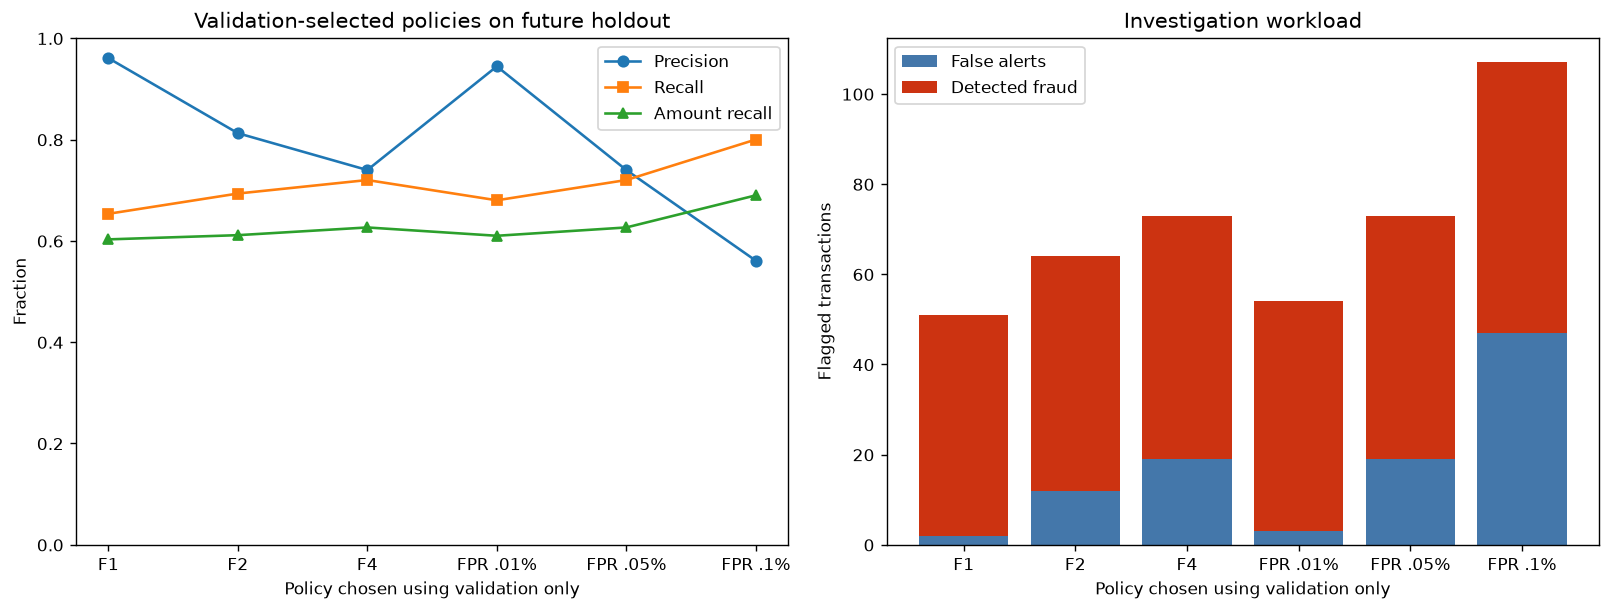

{'反復3報告': {'iteration': 3,
  'request': 'テストの不正が75件しかない点と、検証F2閾値がほぼ1である点を再確認してください。検証区間だけでF1・F2・F4および正常取引の誤検知率上限を選び、将来側のprecision・recall・誤検知件数・金額recallを比較してください。固定モデル・固定閾値の層化および時間ブロックbootstrapで不確実性を示し、運用可能との断定を避けてください。',
  'reason': '閾値によって正常顧客への負荷が大きく変わり、75件では点推定のみでは過度に確信するため',
  'result': {'recall_stable': False,
   'max_relative_deviation': 0.22448979591836743,
   'bootstrap_AP_95': {'stratified': [0.6542738666560264, 0.8549163145796086],
    'hour_block': [0.5652801012647038, 0.8632075129211699]},
   'bootstrap_skipped': {'stratified': 0, 'hour_block': 0}},
  'evidence': 'このセルの6ポリシー表、感度report、200回ずつの区間表と負荷図',
  'remaining_limits': 'bootstrapは固定モデルと固定閾値に条件づけられ、学習・閾値選択の不確実性を含まない。8時間ブロックしかなく部分時間区間もある。カード単位依存や将来の率変化を保証しない。FPR上限は検証上の制約であり将来にも成り立つとは限らない。実際のコストと調査容量は未指定。'}}

In [10]:
request3 = 'テストの不正が75件しかない点と、検証F2閾値がほぼ1である点を再確認してください。検証区間だけでF1・F2・F4および正常取引の誤検知率上限を選び、将来側のprecision・recall・誤検知件数・金額recallを比較してください。固定モデル・固定閾値の層化および時間ブロックbootstrapで不確実性を示し、運用可能との断定を避けてください。'
with phase('反復3：閾値・監視負荷・不確実性'):
    policy_rows=[]
    vp,vr,vt=precision_recall_curve(valid.Class,val_score)
    thresholds={}
    for beta in [1,2,4]:
        fb=(1+beta**2)*vp[:-1]*vr[:-1]/np.maximum(beta**2*vp[:-1]+vr[:-1],1e-15)
        thresholds[f'validation F{beta}']=float(vt[np.argmax(fb)])
    normal_valid=np.sort(val_score[valid.Class.to_numpy()==0])
    for cap in [.0001,.0005,.001]:
        allowed=int(np.floor(len(normal_valid)*cap))
        threshold=float(np.nextafter(normal_valid[-allowed-1],np.inf))
        thresholds[f'validation FPR <= {cap:g}']=threshold
    for name,t in thresholds.items():
        row=metrics(test.Class,test_score,t,test.Amount,name)
        val_row=metrics(valid.Class,val_score,t,valid.Amount,name)
        row.update({'validation_FP':val_row['FP'],'validation_recall':val_row['recall'],'validation_FPR':val_row['FP']/(valid.Class.eq(0).sum())})
        policy_rows.append(row)
    policy_table=pd.DataFrame(policy_rows)
    display(policy_table[['model','threshold','validation_FP','validation_FPR','validation_recall','precision','recall','FP','FN','alerts','amount_recall']])
    threshold_plan=sensitivity.SensitivityPlan({'policy':list(thresholds)},max_runs=6)
    threshold_sensitivity=sensitivity.run_sensitivity(threshold_plan,lambda policy:float(policy_table.loc[policy_table.model.eq(policy),'recall'].iloc[0]),stability_tolerance=.2)
    display(asdict(threshold_sensitivity))
    y=test.Class.to_numpy(); amounts=test.Amount.to_numpy()
    rng=np.random.default_rng(36)
    neg=np.flatnonzero(y==0); pos=np.flatnonzero(y==1)
    hours=np.floor(test.Time.to_numpy()/3600).astype(int)
    blocks=[np.flatnonzero(hours==h) for h in np.unique(hours)]
    bootstrap_rows=[]; skipped={'stratified':0,'hour_block':0}
    for mode in ['stratified','hour_block']:
        for b in range(200):
            if mode=='stratified': ix=np.concatenate([rng.choice(neg,len(neg),replace=True),rng.choice(pos,len(pos),replace=True)])
            else: ix=np.concatenate([blocks[j] for j in rng.integers(0,len(blocks),len(blocks))])
            yy=y[ix]; ss=test_score[ix]; aa=amounts[ix]
            if np.unique(yy).size!=2 or aa[yy==1].sum()<=0:
                skipped[mode]+=1
                continue
            pred=ss>=selected_threshold
            tp=((yy==1)&pred).sum(); fp=((yy==0)&pred).sum()
            bootstrap_rows.append({'mode':mode,'AP':average_precision_score(yy,ss),'precision':tp/(tp+fp) if tp+fp else 0.,'recall':tp/(yy==1).sum(),'amount_recall':aa[(yy==1)&pred].sum()/aa[yy==1].sum()})
    boot=pd.DataFrame(bootstrap_rows)
    ci=boot.groupby('mode')[['AP','precision','recall','amount_recall']].quantile([.025,.5,.975])
    display(ci)
    print('bootstrap仕様:', {'runs_per_mode':200,'seed':36,'hour_blocks':len(blocks),'skipped':skipped,'model_refit':False,'threshold_reselection':False})
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    labels=['F1','F2','F4','FPR .01%','FPR .05%','FPR .1%']
    x=np.arange(len(labels))
    axes[0].plot(x,policy_table.precision,'o-',label='Precision');axes[0].plot(x,policy_table.recall,'s-',label='Recall');axes[0].plot(x,policy_table.amount_recall,'^-',label='Amount recall')
    axes[0].set(title='Validation-selected policies on future holdout',xlabel='Policy chosen using validation only',ylabel='Fraction',xticks=x,xticklabels=labels,ylim=(0,1));axes[0].legend()
    axes[1].bar(x,policy_table.FP,label='False alerts',color='#4477aa')
    axes[1].bar(x,policy_table.TP,bottom=policy_table.FP,label='Detected fraud',color='#cc3311')
    axes[1].set(title='Investigation workload',xlabel='Policy chosen using validation only',ylabel='Flagged transactions',xticks=x,xticklabels=labels);axes[1].legend()
    fig.tight_layout()
    show_chart(fig,'policy_evaluation','Policy sensitivity and investigation workload','Validation-selected policy','Fraction / flagged transactions','Precision, recall, amount recall, false alerts, detected fraud')
    iteration_history.append({'iteration':3,'request':request3,'reason':'閾値によって正常顧客への負荷が大きく変わり、75件では点推定のみでは過度に確信するため','result':{'recall_stable':threshold_sensitivity.stable,'max_relative_deviation':threshold_sensitivity.max_relative_deviation,'bootstrap_AP_95':{mode:list(boot[boot['mode'].eq(mode)].AP.quantile([.025,.975])) for mode in ['stratified','hour_block']},'bootstrap_skipped':skipped},'evidence':'このセルの6ポリシー表、感度report、200回ずつの区間表と負荷図','remaining_limits':'bootstrapは固定モデルと固定閾値に条件づけられ、学習・閾値選択の不確実性を含まない。8時間ブロックしかなく部分時間区間もある。カード単位依存や将来の率変化を保証しない。FPR上限は検証上の制約であり将来にも成り立つとは限らない。実際のコストと調査容量は未指定。'})
    display({'反復3報告':iteration_history[-1]})
section('iteration_history','# 反復依頼履歴\n\n'+json.dumps(iteration_history,ensure_ascii=False,indent=2)+'\n\n3回で終了。残る制約は長期・顧客ID付きの独立データ、実コスト、較正検証が必要で、同一CSVへの追加探索では解消できない。テストを見て運用閾値を最適化してはいない。')

In [11]:
from ai_data_scientist import insight_engine
with phase('前提manifest・実装制約の確認・まとめ'):
    assumption_manifest=analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'dataset':slug,'n':len(df),'primary':'全件記述、時間順60/20/20の探索評価','target':'不正Class=1'},
        causal_scope='associational',
        sampling={'n':len(df),'seed':36,'description':'記述分析は全件、bootstrap各200回'},
        assumptions=(
            analysis_assumptions.Assumption('time-order','実時刻ではなく経過時間で将来側評価を近似','verified',impact_if_false='データ説明に照合',conclusion_critical=True),
            analysis_assumptions.Assumption('no-fit-leakage','前処理とモデルfitは学習期間、閾値は検証期間のみ','tested',impact_if_false='性能過大評価',conclusion_critical=True),
            analysis_assumptions.Assumption('duplicate-handling','完全重複を保持した記述結果と除外結果を比較','tested',impact_if_false='不正頻度・モデル性能のずれ',conclusion_critical=True),
            analysis_assumptions.Assumption('amount-direction','不正金額中央値が低く平均は高いという方向は6仕様で比較','tested',impact_if_false='単純な金額解釈が変わる',conclusion_critical=True),
            analysis_assumptions.Assumption('iid-inference','Wilson/Mann-Whitney/層化bootstrapの取引独立性','assumed',impact_if_false='p値と区間の信頼度が下がる',conclusion_critical=True),
            analysis_assumptions.Assumption('block-inference','時間ブロックbootstrapで短期依存を近似できる','assumed',impact_if_false='8ブロックしかなく将来の不確実性を十分表せない',conclusion_critical=True),
            analysis_assumptions.Assumption('pca-scope','配布済みPCAのfit範囲が時系列リークを含まない','assumed',impact_if_false='将来側識別性能が過大となりうる',conclusion_critical=True),
            analysis_assumptions.Assumption('future-validity','2日間の欧州2013年データが現在の実運用を代表する','rejected',impact_if_false='実運用性能・現在の不正率へ一般化しない',conclusion_critical=True),
            analysis_assumptions.Assumption('cost-policy','F2が実務コストを反映する','assumed',impact_if_false='最適な運用閾値とは限らない',conclusion_critical=True)))
    assumption_findings=analysis_assumptions.check_manifest(assumption_manifest)
    display({'分析前提manifest':asdict(assumption_manifest),'findings':[asdict(x) for x in assumption_findings]})
    inferred_probe=data_definition.build_manifest(source={},dataset_scope={},variables={'Amount':{'currency':data_definition.FieldValue('通貨推定のテスト','inferred')}})
    inferred_unresolved=inferred_probe.unresolved_fields()
    probe_png=visualization.build_image_output(b'not-a-valid-png-for-metadata-test')
    probe=nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('metadata_probe',outputs=[probe_png])])
    probe_visual=notebook_audit.audit_visual_outputs(probe,(0,))
    print('改善候補再現ログ:',{'inferred_fields_returned':inferred_unresolved,'chart_without_metadata_findings':[asdict(x) for x in probe_visual]})
    summary={
        'frequency':f'全{n:,}件中、不正{k}件（{prevalence*100:.4f}%）。全正常判定でもaccuracy={100*(1-prevalence):.4f}%だがrecall=0。',
        'amount':f'正常/不正の中央値は{amount_summary.loc[0,"50%"]:.2f}/{amount_summary.loc[1,"50%"]:.2f}、平均は{amount_summary.loc[0,"mean"]:.2f}/{amount_summary.loc[1,"mean"]:.2f}（元データ単位）。6仕様で中央値の方向は同じだが差の大きさはstable=False、最大相対偏差{amount_sensitivity.max_relative_deviation:.3f}。',
        'time':'経過26–27時間の不正率は36/1752=2.0548%。2・4時間幅でも26時間を含む区間がピークだが数値は幅に依存。実際の深夜と解釈不可。',
        'features':'V14・V4・V12などの効果量が大きいが匿名化主成分を業務要因へ翻訳できない。Amount・TimeだけのAPは0.00614で、匿名化特徴を含むモデルに比べ弱い。',
        'evaluation':f'時間順テスト56,962件（不正75件）のLRはAP={initial_metrics.iloc[-1].AP:.4f}、precision={initial_metrics.iloc[-1].precision:.4f}、recall={initial_metrics.iloc[-1].recall:.4f}、TP=52・FP=12・FN=23。金額recall={initial_metrics.iloc[-1].amount_recall:.4f}。',
        'stability':f'モデル/重複6仕様のAPは{model_comparison.AP.min():.4f}–{model_comparison.AP.max():.4f}でstable=True、最大相対偏差{model_sensitivity.max_relative_deviation:.4f}。閾値仕様のrecallはstable=False（偏差{threshold_sensitivity.max_relative_deviation:.3f}）。',
        'uncertainty':'APの層化bootstrap95%区間は0.654–0.855、時間ブロックは0.565–0.863。固定モデル・閾値に条件づけた探索区間であり運用保証ではない。'}
    display({'最終結論':summary})
section('assumptions','# 分析前提manifest\n\n```json\n'+json.dumps(asdict(assumption_manifest),ensure_ascii=False,indent=2)+'\n```\n\n警告は無視していない。独立性・8時間ブロックでの近似・配布PCAのfit範囲・F2と実コストの対応は未検証。現在の実運用への代表性は棄却し、記述/関連性の結論に限定する。\n\n```json\n'+json.dumps([asdict(x) for x in assumption_findings],ensure_ascii=False,indent=2)+'\n```')
section('improvements', '# Jupytermind改善候補\n\n|分類|再現条件・関係するセル/ログ|期待する挙動|実際の挙動|影響・回避策|\n|---|---|---|---|---|\n|データ定義の機能不足|このセルのinferred_probe、改善候補再現ログ|未検証定義の一覧取得でunknownとinferredの両方を明示できる|unresolved_fields()はunknownだけを返し、inferredでは空リスト|推定を確定扱いする危険。今回は推定せずunknownにし、利用時は全FieldValue.statusを別途走査する。拡張時は既存unknown専用APIとの互換性に注意|\n|視覚監査の機能不足|このセルのmetadata_probe、改善候補再現ログ|chart metadata未記録や不正な画像を監査で検出する|audit_visual_outputsはmetadata全欠落を検出せず、PNG寸法読取不可もfindingなし|visual_audit=Trueだけで妥当性を保証できない。今回は全図のラベル・glyph警告メタデータを明示し、図を実際に確認した|\n\n**実行環境との切り分け:** 初期の対象Notebookセル実行中にenqueue_writeで同じファイルへMarkdownを追加すると、Jupyter MCP側のセル同期で出力/実行番号の保存が不整合となった。対象セル1でコード実行と取得は済んだのにexecution_countが空、セル0の概要Markdownも残らなかった。これはJupytermind単体の障害と断定しないMCP同期との相互作用であり、候補の独立再現ではない。回避策は本文/図メタデータをメモリに蓄積し、対象Notebookが非実行中に同じカーネルの制御Notebookからenqueue_writeすること。Kaggle APIの公開データ取得は成功。SDKのdataset_view不存在とmetadataのinfoネストはSDK仕様への対応で、Jupytermindの不具合ではない。解析コードのDataFrame構築エラーは利用者コードの修正済み問題。CLI・filesystemの許可ルートの不一致は実行環境の問題で、Jupyterで保存先を作成して解消。ベンチマークランナーは起動していない。')
section('summary','# 最終結論\n\n'+'\n\n'.join(f'**{key}:** {value}' for key,value in summary.items()))
module_usage = {
    'ai_data_scientist.project_manager':('resolve_project, ensure_notebook, ensure_data_dir, enqueue_write','slug検証・保存先固定・データ格納・直列化Notebook書込み'),
    'ai_data_scientist.language_router':('detect_language','日本語判定'),
    'ai_data_scientist.lifecycle':('register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, get_run_status, mark_completed, mark_failed','実行/書込みと終了状態の管理。mark_failedは初回の解析コードエラー経路で直接呼出し済み'),
    'ai_data_scientist.ingestion':('SourceSpec, ingest','SHA確認済みCSVを500000行上限で全件ロード'),
    'ai_data_scientist.eda':('explore','dtype・欠損・基本統計'),
    'ai_data_scientist.cleaning':('clean_dataset','重複除外の感度、行列影響'),
    'ai_data_scientist.data_definition':('FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields','データ定義・出典・unknownの記録'),
    'ai_data_scientist.analysis_assumptions':('Assumption, AnalysisAssumptionManifest, check_manifest','前提と因果スコープ、未検証リスク'),
    'ai_data_scientist.data_quality':('detect_anomalies','意味的スキーマ検査'),
    'ai_data_scientist.sensitivity':('SensitivityPlan, run_sensitivity','頻度・金額・モデル・閾値の有限グリッド'),
    'ai_data_scientist.visualization':('build_image_output','Matplotlib図のPNG MIME出力'),
    'ai_data_scientist.insight_engine':('extract_cited_value, record_insight','保存済み実行出力から数値抽出・根拠付き結論の書込み（制御Notebookで直接呼出し）'),
    'ai_data_scientist.notebook_audit':('audit_visual_outputs, audit_notebook','視覚機能の再現確認・visual_audit=Trueの最終監査')}
section('modules','# 使用したJupytermindモジュール\n\n|直接importしたモジュール|直接呼び出した関数/メソッド|使用目的|\n|---|---|---|\n'+'\n'.join(f'|`{name}`|`{calls}`|{purpose}|' for name,(calls,purpose) in module_usage.items())+'\n\n間接利用は列挙していない。visualization.render_chart/record_chartは未使用。多軸・クラス別密度・PR曲線はMatplotlibとsklearnで作図し、build_image_outputだけ直接利用。stats_analysis.correlationも未使用で、分布差はscipyの順位効果量で分析した。')

改善候補再現ログ: {'inferred_fields_returned': [], 'chart_without_metadata_findings': []}


{'分析前提manifest': {'analysis_scope': {'dataset': 'mlg-ulb/creditcardfraud',
   'n': 284807,
   'primary': '全件記述、時間順60/20/20の探索評価',
   'target': '不正Class=1'},
  'assumptions': ({'id': 'time-order',
    'statement': '実時刻ではなく経過時間で将来側評価を近似',
    'status': 'verified',
    'evidence_cell': None,
    'impact_if_false': 'データ説明に照合',
    'conclusion_critical': True},
   {'id': 'no-fit-leakage',
    'statement': '前処理とモデルfitは学習期間、閾値は検証期間のみ',
    'status': 'tested',
    'evidence_cell': None,
    'impact_if_false': '性能過大評価',
    'conclusion_critical': True},
   {'id': 'duplicate-handling',
    'statement': '完全重複を保持した記述結果と除外結果を比較',
    'status': 'tested',
    'evidence_cell': None,
    'impact_if_false': '不正頻度・モデル性能のずれ',
    'conclusion_critical': True},
   {'id': 'amount-direction',
    'statement': '不正金額中央値が低く平均は高いという方向は6仕様で比較',
    'status': 'tested',
    'evidence_cell': None,
    'impact_if_false': '単純な金額解釈が変わる',
    'conclusion_critical': True},
   {'id': 'iid-inference',
    'statement': 'Wils

{'最終結論': {'frequency': '全284,807件中、不正492件（0.1727%）。全正常判定でもaccuracy=99.8273%だがrecall=0。',
  'amount': '正常/不正の中央値は22.00/9.25、平均は88.29/122.21（元データ単位）。6仕様で中央値の方向は同じだが差の大きさはstable=False、最大相対偏差0.585。',
  'time': '経過26–27時間の不正率は36/1752=2.0548%。2・4時間幅でも26時間を含む区間がピークだが数値は幅に依存。実際の深夜と解釈不可。',
  'features': 'V14・V4・V12などの効果量が大きいが匿名化主成分を業務要因へ翻訳できない。Amount・TimeだけのAPは0.00614で、匿名化特徴を含むモデルに比べ弱い。',
  'evaluation': '時間順テスト56,962件（不正75件）のLRはAP=0.7474、precision=0.8125、recall=0.6933、TP=52・FP=12・FN=23。金額recall=0.6111。',
  'stability': 'モデル/重複6仕様のAPは0.7411–0.7482でstable=True、最大相対偏差0.0084。閾値仕様のrecallはstable=False（偏差0.224）。',
  'uncertainty': 'APの層化bootstrap95%区間は0.654–0.855、時間ブロックは0.565–0.863。固定モデル・閾値に条件づけた探索区間であり運用保証ではない。'}}

In [12]:
def persist_analysis_notebook():
    """Jupyter MCP制御Notebookから、対象Notebook非実行中に呼ぶ。"""
    current=nbformat.read(handle.notebook_path,as_version=4)
    summary_cell=next(c for c in current.cells if c.cell_type=='code' and c.source.startswith('from ai_data_scientist import insight_engine'))
    summary_count=summary_cell.execution_count
    evidence_output='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in summary_cell.outputs)
    patterns={'frequency':r'([0-9.]+%)','amount':r'中央値は([0-9.]+/[0-9.]+)','time':r'(36/1752=2.0548%)','features':r'APは([0-9.]+)','evaluation':r'LRはAP=([0-9.]+)','stability':r'APは([0-9.]+–[0-9.]+)','uncertainty':r'時間ブロックは([0-9.]+–[0-9.]+)'}
    citation_specs=[(key,insight_engine.extract_cited_value({'output':evidence_output},pattern)) for key,pattern in patterns.items()]
    def pack(nb):
        codes=[c for c in nb.cells if c.cell_type=='code']
        for cell in codes:
            chart_keys=[key for key in pending_charts if f"show_chart(fig,'{key}'" in cell.source]
            if chart_keys:
                cell.metadata['chart']={field:'; '.join(str(pending_charts[key][field]) for key in chart_keys) for field in ['title','xlabel','ylabel','legend']}
                cell.metadata['chart']['missing_glyphs']=[item for key in chart_keys for item in pending_charts[key]['missing_glyphs']]
                cell.metadata['chart']['panels']={key:pending_charts[key] for key in chart_keys}
        markdowns=[]
        for key,text in pending_sections.items():
            cell=nbformat.v4.new_markdown_cell(text)
            cell.metadata['section_key']=key
            if key=='summary':
                cell.source+='\n\n```evidence\n'+json.dumps({'execution_count':summary_count,'cited_value':citation_specs[0][1],'claim_type':'descriptive'},ensure_ascii=False)+'\n```'
            markdowns.append(cell)
        intro=next(c for c in markdowns if c.metadata.section_key=='intro')
        provenance_cell=next(c for c in markdowns if c.metadata.section_key=='provenance')
        other=[c for c in markdowns if c.metadata.section_key not in ['intro','provenance']]
        audit_cells=[c for c in codes if c.source.startswith('with phase(\'最終監査')]
        rest=[c for c in codes if c not in audit_cells]
        nb.cells=[intro]+rest[:2]+[provenance_cell]+rest[2:]+other+audit_cells
        nb.metadata['run_id']=run_id
        nb.metadata['provenance']=provenance
        nb.metadata['analysis_assumption_findings']=[asdict(x) for x in assumption_findings]
        nb.metadata['iteration_history']=iteration_history
        nb.metadata['chart_author_review']='4図を確認。英語軸/凡例と日本語説明で単位、分母、尺度を明記。'
    write(pack)
    lifecycle.mark_write_start(run_id)
    phase_log.append({'event':'write_start','purpose':'根拠付きinsight','at':datetime.now(timezone.utc).isoformat()})
    try:
        for key,cited in citation_specs:
            insight_engine.record_insight(handle,summary[key],summary_count,cited,'descriptive' if key in ['frequency','amount','time'] else 'associational',language='ja')
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'event':'write_end','purpose':'根拠付きinsight','at':datetime.now(timezone.utc).isoformat()})
    def place_audit_last(nb):
        audit_cells=[c for c in nb.cells if c.cell_type=='code' and c.source.startswith('with phase(\'最終監査')]
        nb.cells=[c for c in nb.cells if c not in audit_cells]+audit_cells
        nb.metadata['phase_log']=phase_log.copy()
    write(place_audit_last)
    print('直列化保存済み:',handle.notebook_path,'根拠付き結論:',len(citation_specs))
print('保存関数定義済み。対象Notebookと同一カーネルの制御Notebookから、非実行中に呼び出して同期競合を避ける。')

保存関数定義済み。対象Notebookと同一カーネルの制御Notebookから、非実行中に呼び出して同期競合を避ける。


# 分析前の前提manifest

```json
{
  "analysis_scope": {
    "dataset": "mlg-ulb/creditcardfraud",
    "planned": "全件記述、時間順60/20/20、検証区間だけで閾値選択"
  },
  "assumptions": [
    {
      "id": "raw-rows",
      "statement": "主記述では完全重複も観測行として保持",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "頻度と金額の集計が変わる",
      "conclusion_critical": true
    },
    {
      "id": "iid-reference",
      "statement": "Wilson区間と順位検定は取引独立性を仮定",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "推論不確実性が過小となりうる",
      "conclusion_critical": true
    },
    {
      "id": "fixed-policy",
      "statement": "F2を探索的なrecall重視ポリシーとして選ぶ",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "実コストに最適とは限らない",
      "conclusion_critical": true
    }
  ],
  "causal_scope": "associational",
  "sampling": null
}
```

重複保持・独立性・F2選択は解析前にはassumed。重複の影響と閾値の感度は反復で検証し、独立性と実コストは最後まで未解決として報告する。

# データ定義manifest・解釈上の制約

```json
{
  "source": {
    "slug": {
      "value": "mlg-ulb/creditcardfraud",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "filename": {
      "value": "creditcard.csv",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "retrieved_at": {
      "value": "2026-10-01T22:05:57.916303+00:00",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "sha256": {
      "value": "76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "source_url": {
      "value": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "method": {
      "value": "Kaggle Python SDK",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "api_checked_at": {
      "value": "2026-10-01T22:13:23.918729+00:00",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    }
  },
  "dataset_scope": {
    "population": {
      "value": "欧州カード保有者、2013年9月の2日間",
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "independent_transactions": {
      "value": null,
      "status": "unknown",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    },
    "license": {
      "value": [
        {
          "name": "DbCL-1.0"
        }
      ],
      "status": "verified",
      "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    }
  },
  "variables": {
    "Time": {
      "definition": {
        "value": "最初の取引からの経過時間",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "unit": {
        "value": "秒",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "clock_origin": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "Amount": {
      "definition": {
        "value": "取引金額",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "currency": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "loss_equivalence": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "Class": {
      "definition": {
        "value": "1=不正、0=正常",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "label_delay": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V1": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V2": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V3": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V4": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V5": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V6": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V7": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V8": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V9": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V10": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V11": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V12": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V13": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V14": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V15": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V16": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V17": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V18": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V19": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V20": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V21": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V22": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V23": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V24": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V25": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V26": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V27": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    },
    "V28": {
      "definition": {
        "value": "匿名化されたPCA主成分",
        "status": "verified",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "original_feature": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      },
      "pca_fit_scope": {
        "value": null,
        "status": "unknown",
        "source": "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
      }
    }
  },
  "transformations": [
    "解析用経過時間=Time/3600",
    "モデル金額=log1p(Amount)、学習期間だけで標準化"
  ]
}
```

`Time`は経過秒であり実時刻・現地時間帯ではない。「深夜」「営業時間」とは解釈しない。Amountの通貨は取得した説明に明記されていないため元データ単位で示す。V1–V28はPCA主成分であり、商品・地域・年齢などへ対応づけたり因果説明したりできない。PCAの学習対象も不明。カードIDがないため顧客分離・再発・独立性を検証できない。不正ラベル確定遅延と実損失も不明。Wilson区間は独立Bernoulli仮定下の参考値で、母集団一般化の保証ではない。

# 適用しない機能と理由

独立参照データが指定・取得されていないため `data_quality.validate_anomalies` と `dataset_validation.compare_datasets` は適用しない。同じCSVの複製や時系列部分集合を独立データと偽らない。API取得はKaggle SDKで直接実施し、ingestionは検証済みローカルCSVの読み込みに利用。mcp_gateway.run_and_recordは直接Jupyter MCP実行を二重ラップしないため未使用。AutoML・クラスタリング・因果推定は本依頼の範囲外。金額の極端値・ゼロ、繰り返し時刻を不正・誤りと自動認定しない。完全重複は主解析では保持し、反復で除外感度を確認する。

# 図表の選択と読み方

クラス件数は対数軸、金額分布はクラス別に正規化したlog1pヒストグラムとECDFで、少数クラスが埋もれないようにした。時間別では件数、クラス内構成比、不正率を別軸に分け、分母とWilson区間を併記する。最後の時間帯は観測終了による部分区間であり、一時間全体の件数と同等に扱わない。V特徴の順位は全データの記述的効果量で、モデル特徴選択には利用しない。p値は独立性仮定に依存するため、BH補正後でも業務上の意味・因果関係を示さない。

# 不均衡を前提にした評価設計

Timeの60%・80%点を固定境界にして、同一時刻が異なる区間へまたがらないよう学習・検証・テストを分割した。変換と標準化は学習区間のみでfit、閾値は検証区間のF2最大化（recall重視）で選ぶ。SMOTE・under-samplingは行わず、テストの自然な不正率を保持する。学習のclass_weightはbalancedであり、スコアを較正済み不正確率とは解釈しない。APは非補間Average Precisionで、台形積分のPR-AUCとは区別する。ROC-AUCは補助指標。全正常ベースラインは不正recall=0であり、accuracyが高くても役に立たない。amount_recallは検出不正取引金額の割合であり、回収損失や利益ではない。全データEDAを見た後の探索評価なので外部検証なしに運用性能を保証しない。

# 反復依頼履歴

[
  {
    "iteration": 1,
    "request": "完全重複1,081行と金額の右裾が、不正頻度・平均と中央値の逆転・時間帯の偏りという結論を変えるか確認してください。重複保持／除外、金額上位1%の影響、1・2・4時間幅を比較し、経過時間の区間ごとの分母も示してください。",
    "reason": "完全重複と平均・中央値の逆転、時間集約は記述結論に影響しうるため",
    "result": {
      "prevalence_stable": true,
      "prevalence_max_relative_deviation": 0.16586078379602356,
      "amount_median_stable": false,
      "amount_max_relative_deviation": 0.5847058823529413,
      "all_median_differences_negative": true,
      "all_mean_differences_positive": true
    },
    "evidence": "このセルの重複除外報告、6仕様ずつの感度report、時間幅比較表",
    "remaining_limits": "顧客ID不明のため重複が記録誤りか実取引か断定できない。2日間の率の変動は長期傾向ではない。"
  },
  {
    "iteration": 2,
    "request": "初回の識別性能がモデルの線形性、正則化、重複行、時間順分割に依存しないか調べてください。固定した時間境界でモデルと重複保持／除外を比較し、金額・経過時間だけのモデルと層化ランダム分割を参考対照として示してください。テスト結果を使った閾値調整はしないでください。",
    "reason": "線形モデルのみでは匿名化特徴の識別力と時系列外挿の限界を切り分けられないため",
    "result": {
      "AP_stable": true,
      "max_relative_deviation": 0.00842249059577291,
      "time_amount_only_AP": 0.006140730694241004,
      "random_dedup_AP": 0.6747817160932731,
      "model_test_AP_range": [
        0.7410756690795585,
        0.7481584102812674
      ]
    },
    "evidence": "このセルの6仕様比較表、SensitivityReport、2対照モデル表",
    "remaining_limits": "層化ランダム対照は異なるテスト構成なので差をリーク量と解釈しない。全候補は探索評価でありテスト上位を採用するモデル選択ではない。匿名化PCAの元のfit範囲と顧客重複は不明。"
  },
  {
    "iteration": 3,
    "request": "テストの不正が75件しかない点と、検証F2閾値がほぼ1である点を再確認してください。検証区間だけでF1・F2・F4および正常取引の誤検知率上限を選び、将来側のprecision・recall・誤検知件数・金額recallを比較してください。固定モデル・固定閾値の層化および時間ブロックbootstrapで不確実性を示し、運用可能との断定を避けてください。",
    "reason": "閾値によって正常顧客への負荷が大きく変わり、75件では点推定のみでは過度に確信するため",
    "result": {
      "recall_stable": false,
      "max_relative_deviation": 0.22448979591836743,
      "bootstrap_AP_95": {
        "stratified": [
          0.6542738666560264,
          0.8549163145796086
        ],
        "hour_block": [
          0.5652801012647038,
          0.8632075129211699
        ]
      },
      "bootstrap_skipped": {
        "stratified": 0,
        "hour_block": 0
      }
    },
    "evidence": "このセルの6ポリシー表、感度report、200回ずつの区間表と負荷図",
    "remaining_limits": "bootstrapは固定モデルと固定閾値に条件づけられ、学習・閾値選択の不確実性を含まない。8時間ブロックしかなく部分時間区間もある。カード単位依存や将来の率変化を保証しない。FPR上限は検証上の制約であり将来にも成り立つとは限らない。実際のコストと調査容量は未指定。"
  }
]

3回で終了。残る制約は長期・顧客ID付きの独立データ、実コスト、較正検証が必要で、同一CSVへの追加探索では解消できない。テストを見て運用閾値を最適化してはいない。

# 分析前提manifest

```json
{
  "analysis_scope": {
    "dataset": "mlg-ulb/creditcardfraud",
    "n": 284807,
    "primary": "全件記述、時間順60/20/20の探索評価",
    "target": "不正Class=1"
  },
  "assumptions": [
    {
      "id": "time-order",
      "statement": "実時刻ではなく経過時間で将来側評価を近似",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": "データ説明に照合",
      "conclusion_critical": true
    },
    {
      "id": "no-fit-leakage",
      "statement": "前処理とモデルfitは学習期間、閾値は検証期間のみ",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": "性能過大評価",
      "conclusion_critical": true
    },
    {
      "id": "duplicate-handling",
      "statement": "完全重複を保持した記述結果と除外結果を比較",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": "不正頻度・モデル性能のずれ",
      "conclusion_critical": true
    },
    {
      "id": "amount-direction",
      "statement": "不正金額中央値が低く平均は高いという方向は6仕様で比較",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": "単純な金額解釈が変わる",
      "conclusion_critical": true
    },
    {
      "id": "iid-inference",
      "statement": "Wilson/Mann-Whitney/層化bootstrapの取引独立性",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "p値と区間の信頼度が下がる",
      "conclusion_critical": true
    },
    {
      "id": "block-inference",
      "statement": "時間ブロックbootstrapで短期依存を近似できる",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "8ブロックしかなく将来の不確実性を十分表せない",
      "conclusion_critical": true
    },
    {
      "id": "pca-scope",
      "statement": "配布済みPCAのfit範囲が時系列リークを含まない",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "将来側識別性能が過大となりうる",
      "conclusion_critical": true
    },
    {
      "id": "future-validity",
      "statement": "2日間の欧州2013年データが現在の実運用を代表する",
      "status": "rejected",
      "evidence_cell": null,
      "impact_if_false": "実運用性能・現在の不正率へ一般化しない",
      "conclusion_critical": true
    },
    {
      "id": "cost-policy",
      "statement": "F2が実務コストを反映する",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "最適な運用閾値とは限らない",
      "conclusion_critical": true
    }
  ],
  "causal_scope": "associational",
  "sampling": {
    "n": 284807,
    "seed": 36,
    "description": "記述分析は全件、bootstrap各200回"
  }
}
```

警告は無視していない。独立性・8時間ブロックでの近似・配布PCAのfit範囲・F2と実コストの対応は未検証。現在の実運用への代表性は棄却し、記述/関連性の結論に限定する。

```json
[
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'iid-inference' has status 'assumed', not verified/tested.",
    "assumption_id": "iid-inference"
  },
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'block-inference' has status 'assumed', not verified/tested.",
    "assumption_id": "block-inference"
  },
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'pca-scope' has status 'assumed', not verified/tested.",
    "assumption_id": "pca-scope"
  },
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'future-validity' has status 'rejected', not verified/tested.",
    "assumption_id": "future-validity"
  },
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'cost-policy' has status 'assumed', not verified/tested.",
    "assumption_id": "cost-policy"
  }
]
```

# Jupytermind改善候補

|分類|再現条件・関係するセル/ログ|期待する挙動|実際の挙動|影響・回避策|
|---|---|---|---|---|
|データ定義の機能不足|このセルのinferred_probe、改善候補再現ログ|未検証定義の一覧取得でunknownとinferredの両方を明示できる|unresolved_fields()はunknownだけを返し、inferredでは空リスト|推定を確定扱いする危険。今回は推定せずunknownにし、利用時は全FieldValue.statusを別途走査する。拡張時は既存unknown専用APIとの互換性に注意|
|視覚監査の機能不足|このセルのmetadata_probe、改善候補再現ログ|chart metadata未記録や不正な画像を監査で検出する|audit_visual_outputsはmetadata全欠落を検出せず、PNG寸法読取不可もfindingなし|visual_audit=Trueだけで妥当性を保証できない。今回は全図のラベル・glyph警告メタデータを明示し、図を実際に確認した|

**実行環境との切り分け:** 初期の対象Notebookセル実行中にenqueue_writeで同じファイルへMarkdownを追加すると、Jupyter MCP側のセル同期で出力/実行番号の保存が不整合となった。対象セル1でコード実行と取得は済んだのにexecution_countが空、セル0の概要Markdownも残らなかった。これはJupytermind単体の障害と断定しないMCP同期との相互作用であり、候補の独立再現ではない。回避策は本文/図メタデータをメモリに蓄積し、対象Notebookが非実行中に同じカーネルの制御Notebookからenqueue_writeすること。Kaggle APIの公開データ取得は成功。SDKのdataset_view不存在とmetadataのinfoネストはSDK仕様への対応で、Jupytermindの不具合ではない。解析コードのDataFrame構築エラーは利用者コードの修正済み問題。CLI・filesystemの許可ルートの不一致は実行環境の問題で、Jupyterで保存先を作成して解消。ベンチマークランナーは起動していない。

# 最終結論

**frequency:** 全284,807件中、不正492件（0.1727%）。全正常判定でもaccuracy=99.8273%だがrecall=0。

**amount:** 正常/不正の中央値は22.00/9.25、平均は88.29/122.21（元データ単位）。6仕様で中央値の方向は同じだが差の大きさはstable=False、最大相対偏差0.585。

**time:** 経過26–27時間の不正率は36/1752=2.0548%。2・4時間幅でも26時間を含む区間がピークだが数値は幅に依存。実際の深夜と解釈不可。

**features:** V14・V4・V12などの効果量が大きいが匿名化主成分を業務要因へ翻訳できない。Amount・TimeだけのAPは0.00614で、匿名化特徴を含むモデルに比べ弱い。

**evaluation:** 時間順テスト56,962件（不正75件）のLRはAP=0.7474、precision=0.8125、recall=0.6933、TP=52・FP=12・FN=23。金額recall=0.6111。

**stability:** モデル/重複6仕様のAPは0.7411–0.7482でstable=True、最大相対偏差0.0084。閾値仕様のrecallはstable=False（偏差0.224）。

**uncertainty:** APの層化bootstrap95%区間は0.654–0.855、時間ブロックは0.565–0.863。固定モデル・閾値に条件づけた探索区間であり運用保証ではない。

```evidence
{"execution_count": 11, "cited_value": "0.1727%", "claim_type": "descriptive"}
```

# 使用したJupytermindモジュール

|直接importしたモジュール|直接呼び出した関数/メソッド|使用目的|
|---|---|---|
|`ai_data_scientist.project_manager`|`resolve_project, ensure_notebook, ensure_data_dir, enqueue_write`|slug検証・保存先固定・データ格納・直列化Notebook書込み|
|`ai_data_scientist.language_router`|`detect_language`|日本語判定|
|`ai_data_scientist.lifecycle`|`register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, get_run_status, mark_completed, mark_failed`|実行/書込みと終了状態の管理。mark_failedは初回の解析コードエラー経路で直接呼出し済み|
|`ai_data_scientist.ingestion`|`SourceSpec, ingest`|SHA確認済みCSVを500000行上限で全件ロード|
|`ai_data_scientist.eda`|`explore`|dtype・欠損・基本統計|
|`ai_data_scientist.cleaning`|`clean_dataset`|重複除外の感度、行列影響|
|`ai_data_scientist.data_definition`|`FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields`|データ定義・出典・unknownの記録|
|`ai_data_scientist.analysis_assumptions`|`Assumption, AnalysisAssumptionManifest, check_manifest`|前提と因果スコープ、未検証リスク|
|`ai_data_scientist.data_quality`|`detect_anomalies`|意味的スキーマ検査|
|`ai_data_scientist.sensitivity`|`SensitivityPlan, run_sensitivity`|頻度・金額・モデル・閾値の有限グリッド|
|`ai_data_scientist.visualization`|`build_image_output`|Matplotlib図のPNG MIME出力|
|`ai_data_scientist.insight_engine`|`extract_cited_value, record_insight`|保存済み実行出力から数値抽出・根拠付き結論の書込み（制御Notebookで直接呼出し）|
|`ai_data_scientist.notebook_audit`|`audit_visual_outputs, audit_notebook`|視覚機能の再現確認・visual_audit=Trueの最終監査|

間接利用は列挙していない。visualization.render_chart/record_chartは未使用。多軸・クラス別密度・PR曲線はMatplotlibとsklearnで作図し、build_image_outputだけ直接利用。stats_analysis.correlationも未使用で、分布差はscipyの順位効果量で分析した。

全284,807件中、不正492件（0.1727%）。全正常判定でもaccuracy=99.8273%だがrecall=0。

```evidence
{"execution_count":11,"cited_value":"0.1727%","claim_type":"descriptive"}
```

正常/不正の中央値は22.00/9.25、平均は88.29/122.21（元データ単位）。6仕様で中央値の方向は同じだが差の大きさはstable=False、最大相対偏差0.585。

```evidence
{"execution_count":11,"cited_value":"22.00/9.25","claim_type":"descriptive"}
```

経過26–27時間の不正率は36/1752=2.0548%。2・4時間幅でも26時間を含む区間がピークだが数値は幅に依存。実際の深夜と解釈不可。

```evidence
{"execution_count":11,"cited_value":"36/1752=2.0548%","claim_type":"descriptive"}
```

V14・V4・V12などの効果量が大きいが匿名化主成分を業務要因へ翻訳できない。Amount・TimeだけのAPは0.00614で、匿名化特徴を含むモデルに比べ弱い。

```evidence
{"execution_count":11,"cited_value":"0.00614","claim_type":"associational"}
```

時間順テスト56,962件（不正75件）のLRはAP=0.7474、precision=0.8125、recall=0.6933、TP=52・FP=12・FN=23。金額recall=0.6111。

```evidence
{"execution_count":11,"cited_value":"0.7474","claim_type":"associational"}
```

モデル/重複6仕様のAPは0.7411–0.7482でstable=True、最大相対偏差0.0084。閾値仕様のrecallはstable=False（偏差0.224）。

```evidence
{"execution_count":11,"cited_value":"0.7411\u20130.7482","claim_type":"associational"}
```

APの層化bootstrap95%区間は0.654–0.855、時間ブロックは0.565–0.863。固定モデル・閾値に条件づけた探索区間であり運用保証ではない。

```evidence
{"execution_count":11,"cited_value":"0.565\u20130.863","claim_type":"associational"}
```

# 最終監査・ライフサイクル状態

全コードセルを上から再実行後、出力保存を待って再監査した。

```json
{
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-36-credit-card-fraud/notebooks/kaggle-v020-kaggle-exp-36-credit-card-fraud.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 12,
    "executed_code_cell_count": 12,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      6,
      7,
      10
    ],
    "insight_cell_count": 7,
    "findings": [],
    "visual_findings": [],
    "ok": true,
    "visual_audit": true
  },
  "lifecycle": {
    "run_id": "v020-exp-36",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-36-credit-card-fraud/notebooks/kaggle-v020-kaggle-exp-36-credit-card-fraud.ipynb",
    "reason": null
  }
}
```

全12コードセルが実行済み、エラー/未実行/視覚所見は0。4枚の図が3つのコードセルに保存され、根拠付き結論は7件。分析前提の警告5件はデータの解釈/適用範囲の制約で、実行エラーとは区別して報告した。

## 再実行時の保存手順

分析セルは上から通常実行できる。Jupyter MCPでは実行中の同一Notebookへの独立writerを避けるため、説明文と図metadataをpending_sections/pending_chartsへ蓄積した。結果を書き直す際は全分析セル実行後、対象を非実行状態にして同一カーネルの制御Notebookセルから `persist_analysis_notebook()` を呼び、対象の最終監査セルを実行する。元の取得日時・SHA-256はローカルデータ履歴で検証される。

## 感度判定の定義

stableは最初の仕様に対する最大相対偏差が20%以下かという明示的な記述基準で、統計的有意性・運用同等性ではない。金額ゼロ除外は対象母集団を正額取引へ変えるため、効果の方向と大きさを分けて解釈する。時間図の対数件数軸では不正0件の時間帯を欠線として表示し、下の構成比/率図では0を表示する。

## 実行セル索引

```json
[
  {
    "index": 1,
    "cell_id": "9ada375f-d08a-4de9-b18e-2c7b76714c55",
    "execution_count": 1,
    "source_first_line": "from pathlib import Path"
  },
  {
    "index": 2,
    "cell_id": "0f006795",
    "execution_count": 2,
    "source_first_line": "import logging"
  },
  {
    "index": 4,
    "cell_id": "59259b15",
    "execution_count": 4,
    "source_first_line": "import inspect"
  },
  {
    "index": 5,
    "cell_id": "5ad507a4",
    "execution_count": 5,
    "source_first_line": "from ai_data_scientist import ingestion"
  },
  {
    "index": 6,
    "cell_id": "e7d76325",
    "execution_count": 6,
    "source_first_line": "import matplotlib.pyplot as plt"
  },
  {
    "index": 7,
    "cell_id": "2d5ca0aa",
    "execution_count": 7,
    "source_first_line": "from sklearn.pipeline import make_pipeline"
  },
  {
    "index": 8,
    "cell_id": "68c2a1fd",
    "execution_count": 8,
    "source_first_line": "iteration_history = []"
  },
  {
    "index": 9,
    "cell_id": "0de1f1b1",
    "execution_count": 9,
    "source_first_line": "from sklearn.ensemble import HistGradientBoostingClassifier"
  },
  {
    "index": 10,
    "cell_id": "11286f9f",
    "execution_count": 10,
    "source_first_line": "request3 = 'テストの不正が75件しかない点と、検証F2閾値がほぼ1である点を再確認してください。検証区間だけでF1・F2・F4および正常取引の誤検知率上限を選び、将来側のprecision・recall・誤検知件数・金額recallを比較してください。固定モデル・固定閾値の層化および時間ブロックbootstrapで不確実性を示し、運用可能との断定を避けてください。'"
  },
  {
    "index": 11,
    "cell_id": "8fddec2c",
    "execution_count": 11,
    "source_first_line": "from ai_data_scientist import insight_engine"
  },
  {
    "index": 12,
    "cell_id": "bd60c4a5",
    "execution_count": 12,
    "source_first_line": "def persist_analysis_notebook():"
  },
  {
    "index": 31,
    "cell_id": "b56b5d72",
    "execution_count": 14,
    "source_first_line": "with phase('最終監査：上から再実行済み・図表と根拠確認'):"
  }
]
```

In [14]:
with phase('最終監査：上から再実行済み・図表と根拠確認'):
    audit_report=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    display({'notebook_audit':asdict(audit_report),'ok':audit_report.ok,'visual_audit':True})
    assert audit_report.ok, 'Notebook監査に未解決エラーがあります'
    assert not audit_report.visual_findings, '図表監査に未解決所見があります'
    assert hashlib.sha256(csv_path.read_bytes()).hexdigest()==provenance['sha256']
    assert len(iteration_history)==3
    assert len(pending_charts)==4
lifecycle.mark_completed(run_id)
completion_status=asdict(lifecycle.get_run_status(run_id))
assert completion_status['state']=='completed'
assert completion_status['active_cell_executions']==0 and completion_status['pending_notebook_writes']==0
print('lifecycle:',json.dumps(completion_status,ensure_ascii=False))
print('再実行記録: カーネル再起動後、全分析コードセルを上からJupyter MCP execute_cellで実行し、最後に本監査セルを実行。Markdown/図metadata/根拠の保存は対象Notebook非実行中の制御Notebookで直列化。')
print('未解決の前提警告:',len(assumption_findings),'運用・因果一般化は行わない。')

lifecycle: {"run_id": "v020-exp-36", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-36-credit-card-fraud/notebooks/kaggle-v020-kaggle-exp-36-credit-card-fraud.ipynb", "reason": null}
再実行記録: カーネル再起動後、全分析コードセルを上からJupyter MCP execute_cellで実行し、最後に本監査セルを実行。Markdown/図metadata/根拠の保存は対象Notebook非実行中の制御Notebookで直列化。
未解決の前提警告: 5 運用・因果一般化は行わない。


{'notebook_audit': {'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-36-credit-card-fraud/notebooks/kaggle-v020-kaggle-exp-36-credit-card-fraud.ipynb',
  'nbformat_valid': True,
  'code_cell_count': 11,
  'executed_code_cell_count': 11,
  'unexecuted_cell_indices': (),
  'error_cell_indices': (),
  'chart_cell_indices': (6, 7, 10),
  'insight_cell_count': 7,
  'findings': (),
  'visual_findings': ()},
 'ok': True,
 'visual_audit': True}